In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import itertools
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scipy.stats as stats

sns.set(font_scale=2) 
sns.set_style("ticks")
import warnings
warnings.filterwarnings("ignore")
dual = ['#B9529F','gray']
triple = ['gray','Tab:red', 'Tab:blue']
triple_ff = ['gray', 'Tab:red','Tab:blue']
sixtus = ['gray', 'Tab:red', 'Tab:blue', 'gray','gray', 'Tab:red', 'Tab:red']
npy = ['gray','darkgreen']
agrp = ['gray','tab:brown']

In [139]:
def preprocess_plot(df, cat_name , name,  palette, order, plotting = False):
    ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

    for column in ls:
        df[column] = pd.to_numeric(df[column])

        if column in ['isi_(ms)', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'AHP_(mV)']:
            param_df = df[df.I_zero != 'silent']
        
        
        else:
            param_df = df
        
        try:
            unique_cat = df[cat_name].unique()
            combos = list(itertools.combinations(unique_cat, 2))

            for combo in combos:
                should_plot = False
                # _, p = stats.ttest_ind(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                #                         param_df[(param_df[cat_name] == combo[1])][column].dropna(),
                #                     equal_var = False)

                _, p = stats.mannwhitneyu(param_df[(param_df[cat_name] == combo[0])][column].dropna(),
                                        param_df[(param_df[cat_name] == combo[1])][column].dropna())
            
                print(column, combo, p)
               

           
        except ValueError:
            
            continue

        if plotting:
            try:
                print(param_df.groupby(cat_name)[column].mean())
                

                sns.set(rc={"figure.figsize": (5.5, 3)})
                sns.set(font_scale=2.5) 
                sns.set_style("ticks")

                ax = sns.boxplot(x=cat_name, y=column, data = param_df, order = order, palette = palette, 
                                saturation=8, linewidth=1.7, showfliers = False, boxprops=dict(alpha=0.5))
                ax = sns.stripplot(x=cat_name, y=column, data = param_df, order=order, 
                                jitter=True, dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = palette, alpha=0.5, zorder=0)
                ax.set_xlabel('')
                ax.set_xticklabels( ('Pre', 'Agg+', 'Agg-', 'ZD', 'Npy', 'AntY1', 'AntY2', 'Y-KD') , rotation=45)
                ax.yaxis.set_major_locator(plt.MaxNLocator(2))
                sns.despine()
                plt.title(column, pad = 20)
                plt.savefig(f'/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/{column}.pdf',
                    dpi=300,bbox_inches='tight', transparent=True)
                plt.show()
            except KeyError:
                pass
                

def proportion(df, column1, column2, cols):
    prop = pd.crosstab(df[column1], df[column2], margins = True).reset_index()
    prop = prop.set_index(column1)
    print(prop)
    prop = prop.iloc[:-1, :-1]
    stat, p, dof, expected  = stats.chi2_contingency(prop)
    print(p)
    
    prop = prop.apply(lambda x: x.div(x.sum()).mul(100), axis=1)
    
    
    prop = prop[cols]
    prop = prop.reset_index()
    return prop

def prop_plot(df, column):
    df.plot(x = column, 
              kind = 'bar', 
              stacked = True,  
              mark_right = False,
              color = ['black', 'darkgray','gray'],
              figsize = (3,5), alpha = 0.7)
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

def remove_outlier(df_in, col_name):
    q1 = df_in[col_name].quantile(0.25)
    q3 = df_in[col_name].quantile(0.75)
    iqr = q3-q1 #Interquartile range
    fence_low  = q1-1.5*iqr
    fence_high = q3+1.5*iqr
    df_out = df_in.loc[(df_in[col_name] > fence_low) & (df_in[col_name] < fence_high)]
    return df_out

# ephys analysis

In [127]:
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)']

include_gal = True

df = pd.read_csv('ephys_analysis_MC.csv')
df['experiment_day'] = df['experiment_day'].apply(lambda x: str(x).upper()[:13])
df.loc[df.Behaviour_6hFD =='No_FD','Behaviour_6hFD'] = 'Pre'
# df.loc[df.Behaviour_6hFD.isin(['Agg+', 'Agg-']),'Behaviour_6hFD'] = 'Post'
df.rename(columns = {'Instant_freq_(Hz)_1/ISI':'Instant_freq_(Hz)'}, inplace =True)

cat = df.Behaviour_6hFD.unique()

if include_gal:
       gal = df[(df.Gal_positive == 'yes') & (df.Behaviour_6hFD == 'Agg+')] 
       no_gal = df[(df.Gal_positive == 'no') & (df.Behaviour_6hFD == 'Agg+')]
       ephys = pd.concat([df[(df.Gal_positive.isin(['Unknown','no']) & (df.Behaviour_6hFD == 'Pre'))], df[df.Behaviour_6hFD != 'Pre']])
       sample_num= int(no_gal.shape[0]/4)
       ephys = pd.concat([ephys, gal.sample(n = sample_num, random_state = 62)]).reset_index(drop = True)

else:
       ephys = df[df.Gal_positive == 'Unknown']
  
# ephys.loc[ephys.Behaviour_6hFD.isin([ 'npy_100_paired']),'Behaviour_6hFD'] = 'npy_100'
     
# ephys.loc[ephys.Behaviour_6hFD.isin(['npy_10', 'npy_100']),'Behaviour_6hFD'] = 'npy'

ephys.to_csv('sampled_ephys_data.csv')

In [128]:
behav = pd.read_csv('ephys_behav.csv')
ephys_behav = pd.merge(ephys, behav, on  = 'ID_mouse')
ephys_behav.columns = [col.replace('(', '_').replace(')', '_') for col in ephys_behav.columns]
ephys_behav.columns = [col.replace(' ', '_').replace('-', '_') for col in ephys_behav.columns]

In [129]:
ephys_behav.columns

Index(['experiment_day', 'sex', 'Gal_positive', 'state', 'estrous_stage',
       'ID_mouse', 'Genotype', 'Behaviour_6hFD', 'Cm_pF_', 'Adaptive',
       'I_zero', 'I_zero_reclassified', '60mV', 'Firing_freq__Hz__I0',
       'Instant_freq__Hz_', 'isi__ms_', 'cat_categ', 'CaT', 'Ih',
       'Ih_at__120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak',
       'area_mV_ms_', 'rheobase_at__60mV__pA_', 'AHP__mV_', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude_pA_',
       'sPSCs_Rise_time', 'sPSCs__decay_', 'AC_I0', 'AC__60', 'Comments',
       'estrous_confirmation', 'pup_intro', 'contact', 'attack',
       'contact_latency', 'attack_latency', 'attack_since_contact'],
      dtype='object')

In [130]:
percent_columns = ['Ih_at__120mV', 'CaT', 'Adaptive', 'Firing_freq__Hz__I0'] 
percentages_df = pd.DataFrame(index=ephys_behav['ID_mouse'].unique())

for column in percent_columns:
    percentages = ephys_behav.groupby('ID_mouse')[column].apply(lambda x: (x == 0).sum() / len(x) * 100)
    percentages_df[column + '_percent_nonzero'] = percentages

silent_percentages = ephys_behav.groupby('ID_mouse')['I_zero_reclassified'].apply(lambda x: (x == 'silent').sum() / len(x) * 100).reset_index(name='I_zero_reclassified' + '_percent_silent')
percentages_df = percentages_df.reset_index()
percentages_df.rename(columns={'index': 'ID_mouse'}, inplace=True)
percentages_df = pd.merge(percentages_df, silent_percentages, on='ID_mouse', how='outer')

percentages_df = pd.merge(percentages_df, behav, on = 'ID_mouse')




In [131]:
for y in percentages_df.columns[1:-6]:
    if y != 'attack_since_contact':  # Skip the contact_latency column
        formula = 'attack_since_contact ~ ' + y
        try:
            model = smf.ols(formula, data=percentages_df).fit()
            anova_results = sm.stats.anova_lm(model, typ=2)
            
            if model.pvalues[y] <0.05:
                print(model.pvalues[y], y, model.rsquared)

                sns.lmplot(x = 'attack_since_contact', y = y, data = percentages_df)
           
        except Exception as e:
            continue

0.01944928104928148 sPSC_Amplitude_pA_ 0.31337716718782116


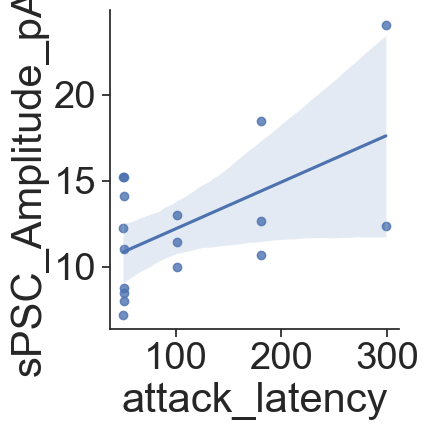

In [132]:
#ephys correlation with behaviour metric
for y in ephys_behav.columns[8:-8]:
    if y != 'contact_latency':  # Skip the contact_latency column
        formula = 'attack_latency ~ ' + y
        try:
            model = smf.ols(formula, data=ephys_behav).fit()
            anova_results = sm.stats.anova_lm(model, typ=2)
            
            if model.pvalues[y] <0.05:
                print(model.pvalues[y], y, model.rsquared)

                sns.lmplot(x = 'attack_latency', y = y, data = ephys_behav)
                plt.show()
           
        except Exception as e:
            continue
    

In [133]:
ephys.Behaviour_6hFD.unique()

array(['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy1r_antag', 'npy2r_antag',
       'npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100', 'agrp_100',
       'ZD7288', 'ZD7288_20', 'npykd'], dtype=object)

## all properties

Cm(pF) ('Pre', 'Agg+') 0.5478128358005985
Cm(pF) ('Pre', 'Agg-') 0.9581390074603655
Firing_freq_(Hz)_I0 ('Pre', 'Agg+') 0.00504719432915003
Firing_freq_(Hz)_I0 ('Pre', 'Agg-') 0.056508303792092644
Firing_freq_(Hz)_I0 ('Pre', 'npy1r_antag') 0.252688674884768
Firing_freq_(Hz)_I0 ('Pre', 'npy2r_antag') 0.6743023544045252
Firing_freq_(Hz)_I0 ('Pre', 'npy_100') 0.023922300921200183
Firing_freq_(Hz)_I0 ('Pre', 'ZD7288') 0.0017170461164481739
Firing_freq_(Hz)_I0 ('Pre', 'npykd') 0.42663831886959436
Firing_freq_(Hz)_I0 ('Agg+', 'Agg-') 0.0001746705231566079
Firing_freq_(Hz)_I0 ('Agg+', 'npy1r_antag') 0.008876756095403162
Firing_freq_(Hz)_I0 ('Agg+', 'npy2r_antag') 0.04365037534398598
Firing_freq_(Hz)_I0 ('Agg+', 'npy_100') 0.6134130854657027
Firing_freq_(Hz)_I0 ('Agg+', 'ZD7288') 0.07945550021001034
Firing_freq_(Hz)_I0 ('Agg+', 'npykd') 0.010013895179968379
Firing_freq_(Hz)_I0 ('Agg-', 'npy1r_antag') 0.7211105212310518
Firing_freq_(Hz)_I0 ('Agg-', 'npy2r_antag') 0.595301804358754
Firing_freq_(

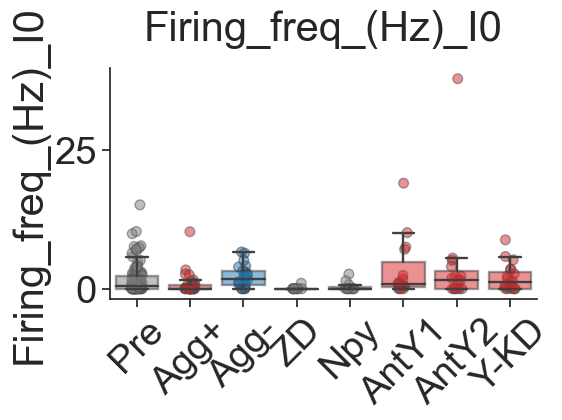

Instant_freq_(Hz) ('Pre', 'Agg+') 0.0032728514563841716
Instant_freq_(Hz) ('Pre', 'Agg-') 0.14694272991012025
Instant_freq_(Hz) ('Pre', 'npy1r_antag') 0.3394466172966044
Instant_freq_(Hz) ('Pre', 'npy2r_antag') 0.6712497414146636
Instant_freq_(Hz) ('Pre', 'npy_100') 0.02300905310648627
Instant_freq_(Hz) ('Pre', 'ZD7288') 0.0021556187795441304
Instant_freq_(Hz) ('Pre', 'npykd') 0.41607433679195127
Instant_freq_(Hz) ('Agg+', 'Agg-') 0.0004527206589903793
Instant_freq_(Hz) ('Agg+', 'npy1r_antag') 0.007906667936953339
Instant_freq_(Hz) ('Agg+', 'npy2r_antag') 0.04361340903129286
Instant_freq_(Hz) ('Agg+', 'npy_100') 0.5706486306057815
Instant_freq_(Hz) ('Agg+', 'ZD7288') 0.08697981450001754
Instant_freq_(Hz) ('Agg+', 'npykd') 0.010220715043157145
Instant_freq_(Hz) ('Agg-', 'npy1r_antag') 0.9381289063266207
Instant_freq_(Hz) ('Agg-', 'npy2r_antag') 0.7905716654506721
Instant_freq_(Hz) ('Agg-', 'npy_100') 0.008134465584857038
Instant_freq_(Hz) ('Agg-', 'ZD7288') 0.0018326276980825283
Instant

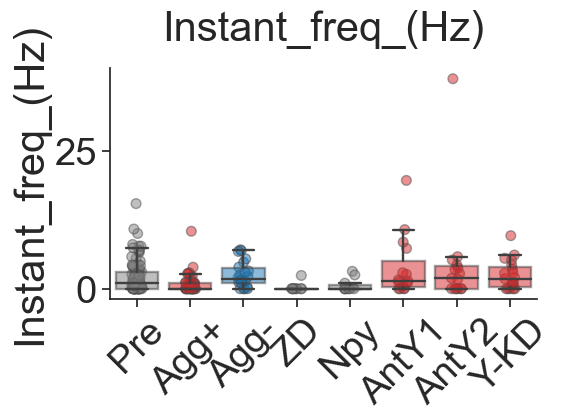

isi_(ms) ('Pre', 'Agg+') 0.5416705080321197
isi_(ms) ('Pre', 'Agg-') 0.0656361540509657
isi_(ms) ('Pre', 'npy1r_antag') 0.2975071455695215
isi_(ms) ('Pre', 'npy2r_antag') 0.02563927200880558
isi_(ms) ('Pre', 'npy_100') 0.5515446520781774
isi_(ms) ('Pre', 'ZD7288') 0.958904109589041
isi_(ms) ('Pre', 'npykd') 0.24445569446984405
isi_(ms) ('Agg+', 'Agg-') 0.005426487032638743
isi_(ms) ('Agg+', 'npy1r_antag') 0.20138256659070575
isi_(ms) ('Agg+', 'npy2r_antag') 0.0031580702443155086
isi_(ms) ('Agg+', 'npy_100') 0.9676423860879706
isi_(ms) ('Agg+', 'ZD7288') 0.6027418291290804
isi_(ms) ('Agg+', 'npykd') 0.08356328687917033
isi_(ms) ('Agg-', 'npy1r_antag') 0.6566808075579458
isi_(ms) ('Agg-', 'npy2r_antag') 0.2471599732119072
isi_(ms) ('Agg-', 'npy_100') 0.11784005468215993
isi_(ms) ('Agg-', 'ZD7288') 0.42105263157894735
isi_(ms) ('Agg-', 'npykd') 0.6899948772616324
isi_(ms) ('npy1r_antag', 'npy2r_antag') 0.3027893674905606
isi_(ms) ('npy1r_antag', 'npy_100') 0.5208791208791208
isi_(ms) ('np

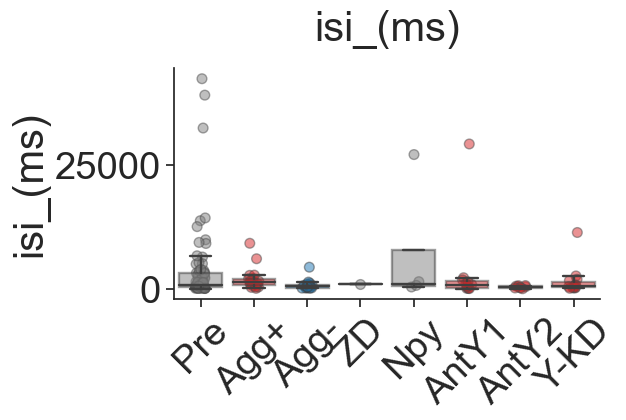

CaT ('Pre', 'Agg+') 0.8274026002433236
CaT ('Pre', 'Agg-') 0.5457198326477843
CaT ('Pre', 'npy1r_antag') 0.416874334882375
CaT ('Pre', 'npy2r_antag') 0.4283661006711814
CaT ('Pre', 'npy_100') 0.7678254333041528
CaT ('Pre', 'ZD7288') 0.6255791227700008
CaT ('Pre', 'npykd') 0.2749082598502871
CaT ('Agg+', 'Agg-') 0.43466939817962635
CaT ('Agg+', 'npy1r_antag') 0.5915591745421165
CaT ('Agg+', 'npy2r_antag') 0.5718446518520441
CaT ('Agg+', 'npy_100') 0.7982030403344371
CaT ('Agg+', 'ZD7288') 0.7690368231397673
CaT ('Agg+', 'npykd') 0.3255728056188747
CaT ('Agg-', 'npy1r_antag') 0.16745288464179808
CaT ('Agg-', 'npy2r_antag') 0.23228925181341442
CaT ('Agg-', 'npy_100') 0.2823571409583424
CaT ('Agg-', 'ZD7288') 0.4969394928289175
CaT ('Agg-', 'npykd') 0.13214757065294017
CaT ('npy1r_antag', 'npy2r_antag') 0.9601073523051299
CaT ('npy1r_antag', 'npy_100') 1.0
CaT ('npy1r_antag', 'ZD7288') 0.7839136702502763
CaT ('npy1r_antag', 'npykd') 0.6165210824642668
CaT ('npy2r_antag', 'npy_100') 0.87717

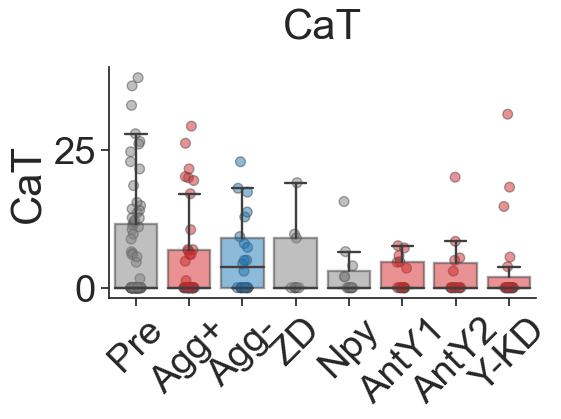

Ih_at_-120mV ('Pre', 'Agg+') 0.031965742840059305
Ih_at_-120mV ('Pre', 'Agg-') 0.4790416294467804
Ih_at_-120mV ('Pre', 'npy1r_antag') 0.9360038311341023
Ih_at_-120mV ('Pre', 'npy2r_antag') 0.7896415836944567
Ih_at_-120mV ('Pre', 'npy_100') 0.02989713497840224
Ih_at_-120mV ('Pre', 'ZD7288') 0.0004433783548300275
Ih_at_-120mV ('Pre', 'npykd') 0.7632455573749046
Ih_at_-120mV ('Agg+', 'Agg-') 0.0026668129735311
Ih_at_-120mV ('Agg+', 'npy1r_antag') 0.18732059129588352
Ih_at_-120mV ('Agg+', 'npy2r_antag') 0.12748860953753732
Ih_at_-120mV ('Agg+', 'npy_100') 0.29789646222005584
Ih_at_-120mV ('Agg+', 'ZD7288') 0.0017136404394727247
Ih_at_-120mV ('Agg+', 'npykd') 0.034500877206264366
Ih_at_-120mV ('Agg-', 'npy1r_antag') 0.5054880344356945
Ih_at_-120mV ('Agg-', 'npy2r_antag') 0.36334541130232734
Ih_at_-120mV ('Agg-', 'npy_100') 0.0025909920943359187
Ih_at_-120mV ('Agg-', 'ZD7288') 3.1739315352409464e-05
Ih_at_-120mV ('Agg-', 'npykd') 0.8650353939353734
Ih_at_-120mV ('npy1r_antag', 'npy2r_antag')

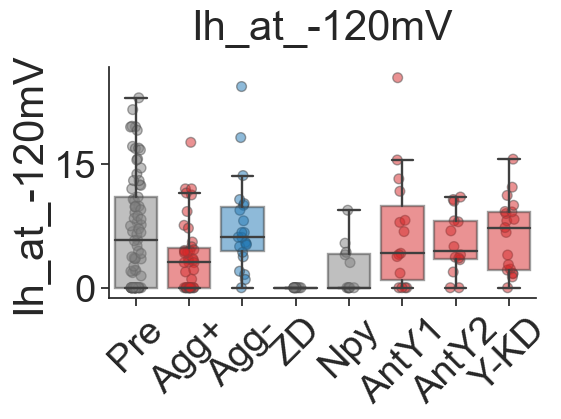

AP_ampl ('Pre', 'Agg+') 0.09305252349251009
AP_ampl ('Pre', 'Agg-') 0.5937244613471877
AP_ampl ('Pre', 'npy1r_antag') 0.0018155323915409233
AP_ampl ('Pre', 'npy2r_antag') 0.027460667809152076
AP_ampl ('Pre', 'npy_100') 0.27455327143137165
AP_ampl ('Pre', 'ZD7288') 0.6327212360478085
AP_ampl ('Pre', 'npykd') 0.013460540369903127
AP_ampl ('Agg+', 'Agg-') 0.4941107336026388
AP_ampl ('Agg+', 'npy1r_antag') 0.0446544564885533
AP_ampl ('Agg+', 'npy2r_antag') 0.4028786243966609
AP_ampl ('Agg+', 'npy_100') 0.9676343900778256
AP_ampl ('Agg+', 'ZD7288') 0.8622171384561883
AP_ampl ('Agg+', 'npykd') 0.18359480204797496
AP_ampl ('Agg-', 'npy1r_antag') 0.006323780925748658
AP_ampl ('Agg-', 'npy2r_antag') 0.09459935246991134
AP_ampl ('Agg-', 'npy_100') 0.3420369104579631
AP_ampl ('Agg-', 'ZD7288') 0.8421052631578947
AP_ampl ('Agg-', 'npykd') 0.07117241510559746
AP_ampl ('npy1r_antag', 'npy2r_antag') 0.695894823170777
AP_ampl ('npy1r_antag', 'npy_100') 0.21208791208791208
AP_ampl ('npy1r_antag', 'ZD72

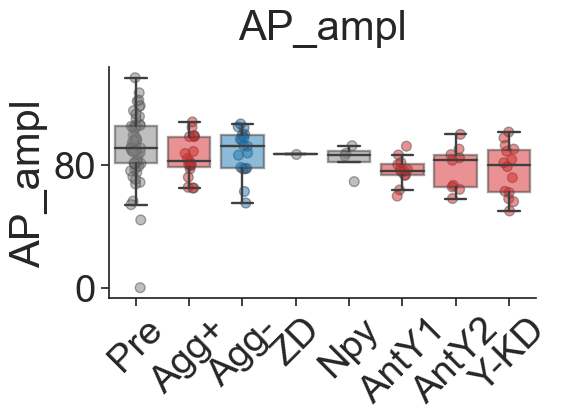

AP_halfwidth ('Pre', 'Agg+') 0.6346395650350448
AP_halfwidth ('Pre', 'Agg-') 0.08308572507672611
AP_halfwidth ('Pre', 'npy1r_antag') 0.9807412483433126
AP_halfwidth ('Pre', 'npy2r_antag') 0.8492890116809699
AP_halfwidth ('Pre', 'npy_100') 0.34279577085312163
AP_halfwidth ('Pre', 'ZD7288') 0.8078449203901159
AP_halfwidth ('Pre', 'npykd') 0.3178989134160016
AP_halfwidth ('Agg+', 'Agg-') 0.08278932948645706
AP_halfwidth ('Agg+', 'npy1r_antag') 0.9838071670543952
AP_halfwidth ('Agg+', 'npy2r_antag') 0.6051489167801112
AP_halfwidth ('Agg+', 'npy_100') 0.2732818831738256
AP_halfwidth ('Agg+', 'ZD7288') 1.0
AP_halfwidth ('Agg+', 'npykd') 0.635576022523606
AP_halfwidth ('Agg-', 'npy1r_antag') 0.18847057213355278
AP_halfwidth ('Agg-', 'npy2r_antag') 0.3672599040677643
AP_halfwidth ('Agg-', 'npy_100') 0.9659827751335944
AP_halfwidth ('Agg-', 'ZD7288') 0.6473550172983791
AP_halfwidth ('Agg-', 'npykd') 0.022468620794247395
AP_halfwidth ('npy1r_antag', 'npy2r_antag') 0.9149684068240318
AP_halfwidth

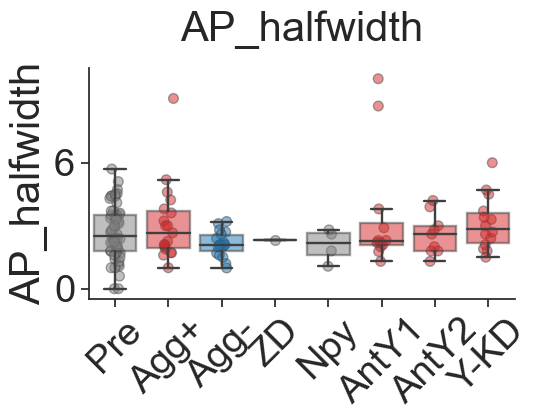

AP_time_to_peak ('Pre', 'Agg+') 0.5849133247979129
AP_time_to_peak ('Pre', 'Agg-') 0.8815081361133289
AP_time_to_peak ('Pre', 'npy1r_antag') 0.018616372722913523
AP_time_to_peak ('Pre', 'npy2r_antag') 0.2066475707652392
AP_time_to_peak ('Pre', 'npy_100') 0.2937816501917322
AP_time_to_peak ('Pre', 'ZD7288') 0.5300813969081073
AP_time_to_peak ('Pre', 'npykd') 0.03226031577205425
AP_time_to_peak ('Agg+', 'Agg-') 0.47454164877682115
AP_time_to_peak ('Agg+', 'npy1r_antag') 0.05122294495765199
AP_time_to_peak ('Agg+', 'npy2r_antag') 0.18351748485021924
AP_time_to_peak ('Agg+', 'npy_100') 0.3098000394161794
AP_time_to_peak ('Agg+', 'ZD7288') 0.8620112486109536
AP_time_to_peak ('Agg+', 'npykd') 0.05801652263327501
AP_time_to_peak ('Agg-', 'npy1r_antag') 0.004385123090463345
AP_time_to_peak ('Agg-', 'npy2r_antag') 0.27772782379138483
AP_time_to_peak ('Agg-', 'npy_100') 0.15837452562515886
AP_time_to_peak ('Agg-', 'ZD7288') 0.40904435007858275
AP_time_to_peak ('Agg-', 'npykd') 0.0379117238293848

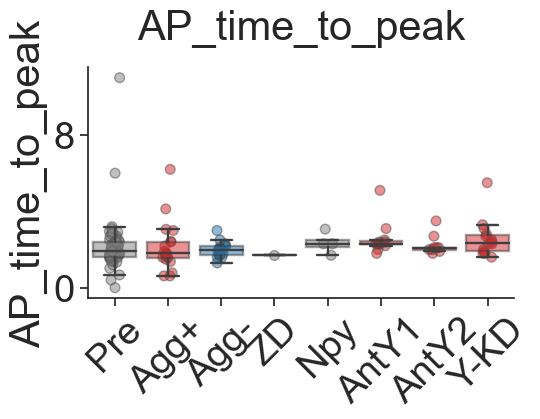

area(mV_ms) ('Pre', 'Agg+') 0.4533985805296278
area(mV_ms) ('Pre', 'Agg-') 0.03441863923068174
area(mV_ms) ('Pre', 'npy1r_antag') 0.33816577593712915
area(mV_ms) ('Pre', 'npy2r_antag') 0.08560642778299489
area(mV_ms) ('Pre', 'npy_100') 0.3290331859667589
area(mV_ms) ('Pre', 'ZD7288') 0.5908385974339502
area(mV_ms) ('Pre', 'npykd') 0.3438411217727211
area(mV_ms) ('Agg+', 'Agg-') 0.637603520086307
area(mV_ms) ('Agg+', 'npy1r_antag') 0.8871018302617665
area(mV_ms) ('Agg+', 'npy2r_antag') 0.4311145587687827
area(mV_ms) ('Agg+', 'npy_100') 0.9031158454078924
area(mV_ms) ('Agg+', 'ZD7288') 0.8622171384561883
area(mV_ms) ('Agg+', 'npykd') 0.9274290374340824
area(mV_ms) ('Agg-', 'npy1r_antag') 0.9831126875838702
area(mV_ms) ('Agg-', 'npy2r_antag') 0.6251055995506551
area(mV_ms) ('Agg-', 'npy_100') 0.9022556390977444
area(mV_ms) ('Agg-', 'ZD7288') 1.0
area(mV_ms) ('Agg-', 'npykd') 0.19001098064722566
area(mV_ms) ('npy1r_antag', 'npy2r_antag') 0.45554509378932984
area(mV_ms) ('npy1r_antag', 'npy

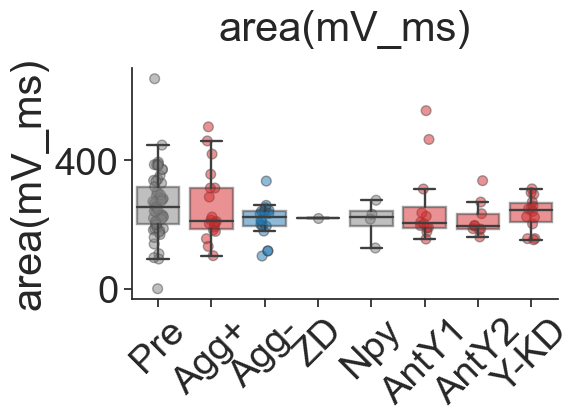

rheobase_at_-60mV_(pA) ('Pre', 'Agg+') 0.03249932372033951
rheobase_at_-60mV_(pA) ('Pre', 'Agg-') 0.1262400119204945
rheobase_at_-60mV_(pA) ('Pre', 'npy1r_antag') 0.19554128779794
rheobase_at_-60mV_(pA) ('Pre', 'npy2r_antag') 0.5863628644426506
rheobase_at_-60mV_(pA) ('Pre', 'npy_100') 0.0015268567927832694
rheobase_at_-60mV_(pA) ('Pre', 'ZD7288') 0.038998267330366196
rheobase_at_-60mV_(pA) ('Pre', 'npykd') 0.13296800337805958
rheobase_at_-60mV_(pA) ('Agg+', 'Agg-') 0.5486092717315554
rheobase_at_-60mV_(pA) ('Agg+', 'npy1r_antag') 0.6488231174941113
rheobase_at_-60mV_(pA) ('Agg+', 'npy2r_antag') 0.36142768267171
rheobase_at_-60mV_(pA) ('Agg+', 'npy_100') 0.12094457787165978
rheobase_at_-60mV_(pA) ('Agg+', 'ZD7288') 0.0032687272269499
rheobase_at_-60mV_(pA) ('Agg+', 'npykd') 0.25689365255604846
rheobase_at_-60mV_(pA) ('Agg-', 'npy1r_antag') 1.0
rheobase_at_-60mV_(pA) ('Agg-', 'npy2r_antag') 0.7741936507867566
rheobase_at_-60mV_(pA) ('Agg-', 'npy_100') 0.04054050050326848
rheobase_at_-60

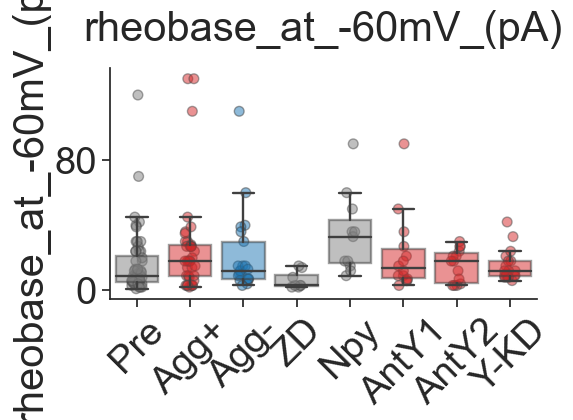

AHP_(mV) ('Pre', 'Agg+') 0.22543042392286838
AHP_(mV) ('Pre', 'Agg-') 0.5923087973031331
AHP_(mV) ('Pre', 'npy1r_antag') 0.09586259921170794
AHP_(mV) ('Pre', 'npy2r_antag') 0.5245532320773512
AHP_(mV) ('Pre', 'npy_100') 0.2538491280734779
AHP_(mV) ('Pre', 'ZD7288') 1.0
AHP_(mV) ('Pre', 'npykd') 2.0321552945708384e-06
AHP_(mV) ('Agg+', 'Agg-') 0.4383652440586959
AHP_(mV) ('Agg+', 'npy1r_antag') 0.2476563189933242
AHP_(mV) ('Agg+', 'npy2r_antag') 0.8056614680033746
AHP_(mV) ('Agg+', 'npy_100') 0.8392311429565961
AHP_(mV) ('Agg+', 'ZD7288') 0.43463746969213013
AHP_(mV) ('Agg+', 'npykd') 6.127290586742151e-05
AHP_(mV) ('Agg-', 'npy1r_antag') 0.13279539648494482
AHP_(mV) ('Agg-', 'npy2r_antag') 0.8369711950016507
AHP_(mV) ('Agg-', 'npy_100') 0.43417634996582366
AHP_(mV) ('Agg-', 'ZD7288') 0.8421052631578947
AHP_(mV) ('Agg-', 'npykd') 2.280084288246825e-05
AHP_(mV) ('npy1r_antag', 'npy2r_antag') 0.39361500571651586
AHP_(mV) ('npy1r_antag', 'npy_100') 1.0
AHP_(mV) ('npy1r_antag', 'ZD7288') 0.

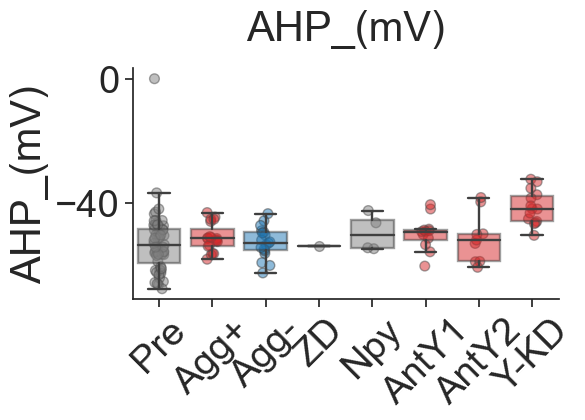

Vm ('Pre', 'Agg+') 0.23383222912705826
Vm ('Pre', 'Agg-') 0.4065705131864982
Vm ('Pre', 'npy1r_antag') 0.054906646563235836
Vm ('Pre', 'npy2r_antag') 0.5186292593615516
Vm ('Pre', 'npy_100') 0.9602675222259763
Vm ('Pre', 'ZD7288') 0.050421479951831376
Vm ('Pre', 'npykd') 2.1730199921727061e-07
Vm ('Agg+', 'Agg-') 0.7347414454457386
Vm ('Agg+', 'npy1r_antag') 0.4480903061668098
Vm ('Agg+', 'npy2r_antag') 0.8969481626462087
Vm ('Agg+', 'npy_100') 0.38218824970030474
Vm ('Agg+', 'ZD7288') 0.28885964797367114
Vm ('Agg+', 'npykd') 9.254618797734081e-05
Vm ('Agg-', 'npy1r_antag') 0.15927452165285128
Vm ('Agg-', 'npy2r_antag') 0.6989930202150316
Vm ('Agg-', 'npy_100') 0.3494577006995545
Vm ('Agg-', 'ZD7288') 0.1572500789959627
Vm ('Agg-', 'npykd') 0.0001423765574549236
Vm ('npy1r_antag', 'npy2r_antag') 0.3400858902842717
Vm ('npy1r_antag', 'npy_100') 0.19445981020349767
Vm ('npy1r_antag', 'ZD7288') 0.8580276569875211
Vm ('npy1r_antag', 'npykd') 0.0031965719549487096
Vm ('npy2r_antag', 'npy_10

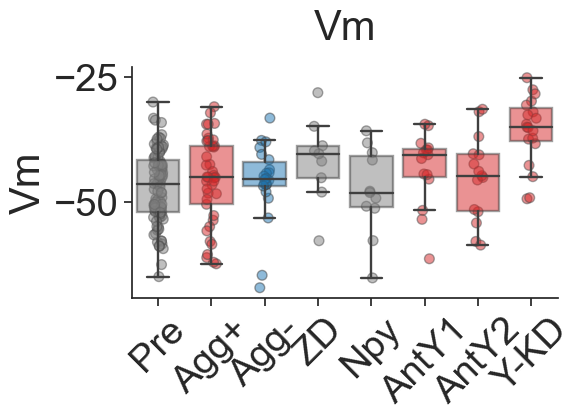

Input_Resistance ('Pre', 'Agg+') 0.007391280111677393
Input_Resistance ('Pre', 'Agg-') 0.9966422937119996
Input_Resistance ('Pre', 'npy1r_antag') 0.12800381529415228
Input_Resistance ('Pre', 'npy2r_antag') 0.3878665827742124
Input_Resistance ('Pre', 'npy_100') 0.859793442923109
Input_Resistance ('Pre', 'ZD7288') 0.00044327207068689816
Input_Resistance ('Pre', 'npykd') 8.294085131497217e-05
Input_Resistance ('Agg+', 'Agg-') 0.0690903002152292
Input_Resistance ('Agg+', 'npy1r_antag') 0.6568404698264272
Input_Resistance ('Agg+', 'npy2r_antag') 0.3585723735392867
Input_Resistance ('Agg+', 'npy_100') 0.3438757158456933
Input_Resistance ('Agg+', 'ZD7288') 0.03379412458526728
Input_Resistance ('Agg+', 'npykd') 0.06378406399280104
Input_Resistance ('Agg-', 'npy1r_antag') 0.24603234909826666
Input_Resistance ('Agg-', 'npy2r_antag') 0.57009529631342
Input_Resistance ('Agg-', 'npy_100') 0.8336348830246822
Input_Resistance ('Agg-', 'ZD7288') 0.0021541104518153133
Input_Resistance ('Agg-', 'npykd')

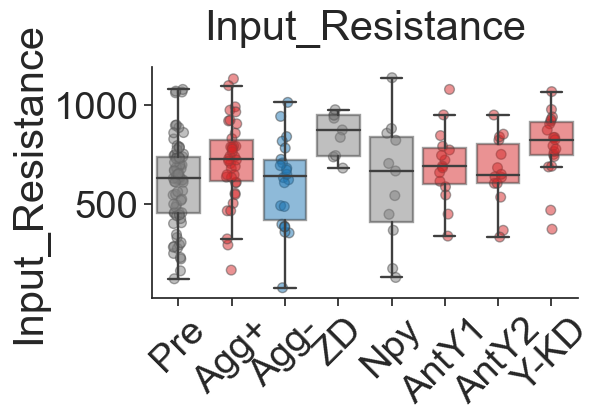

sPSC_frequency ('Pre', 'Agg+') 0.8875758951849015
sPSC_frequency ('Pre', 'Agg-') 0.10819724752370144
sPSC_frequency ('Pre', 'npy1r_antag') 0.011956030052197754
sPSC_frequency ('Pre', 'npy2r_antag') 0.12188012610506029
sPSC_frequency ('Pre', 'npy_100') 0.6352562959972483
sPSC_frequency ('Pre', 'ZD7288') 8.427156354363181e-05
sPSC_frequency ('Pre', 'npykd') 0.2816305717947646
sPSC_frequency ('Agg+', 'Agg-') 0.1282279806820076
sPSC_frequency ('Agg+', 'npy1r_antag') 0.02177042761884632
sPSC_frequency ('Agg+', 'npy2r_antag') 0.1671063968798766
sPSC_frequency ('Agg+', 'npy_100') 0.6954418919818707
sPSC_frequency ('Agg+', 'ZD7288') 0.0005623535384817763
sPSC_frequency ('Agg+', 'npykd') 0.40889177634185336
sPSC_frequency ('Agg-', 'npy1r_antag') 0.0015203172563771129
sPSC_frequency ('Agg-', 'npy2r_antag') 0.00988652142502657
sPSC_frequency ('Agg-', 'npy_100') 0.33936996262299535
sPSC_frequency ('Agg-', 'ZD7288') 0.0016887282854299345
sPSC_frequency ('Agg-', 'npykd') 0.03712596135002326
sPSC_fre

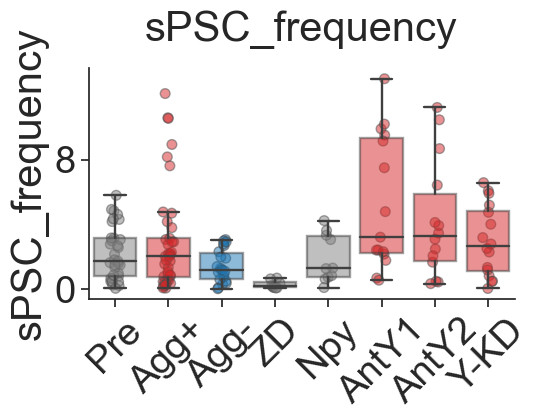

sPSC_Amplitude(pA) ('Pre', 'Agg+') 0.9739733733738629
sPSC_Amplitude(pA) ('Pre', 'Agg-') 0.050095923041863805
sPSC_Amplitude(pA) ('Pre', 'npy1r_antag') 0.664463697288834
sPSC_Amplitude(pA) ('Pre', 'npy2r_antag') 0.898186424074502
sPSC_Amplitude(pA) ('Pre', 'npy_100') 0.8292728449920526
sPSC_Amplitude(pA) ('Pre', 'ZD7288') 0.002609113660260992
sPSC_Amplitude(pA) ('Pre', 'npykd') 0.2162254985993588
sPSC_Amplitude(pA) ('Agg+', 'Agg-') 0.040566424695120715
sPSC_Amplitude(pA) ('Agg+', 'npy1r_antag') 0.6976071656809522
sPSC_Amplitude(pA) ('Agg+', 'npy2r_antag') 0.9537744259130791
sPSC_Amplitude(pA) ('Agg+', 'npy_100') 0.9621528136059516
sPSC_Amplitude(pA) ('Agg+', 'ZD7288') 0.002558666432934207
sPSC_Amplitude(pA) ('Agg+', 'npykd') 0.1686812205871937
sPSC_Amplitude(pA) ('Agg-', 'npy1r_antag') 0.7451488435418439
sPSC_Amplitude(pA) ('Agg-', 'npy2r_antag') 0.21685720304576017
sPSC_Amplitude(pA) ('Agg-', 'npy_100') 0.16598539740736384
sPSC_Amplitude(pA) ('Agg-', 'ZD7288') 0.013642787090909672
sPS

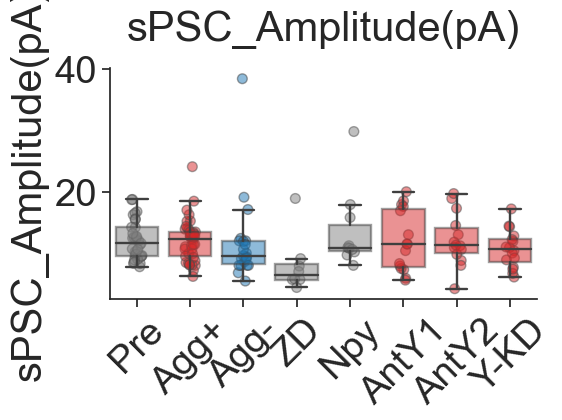

sPSCs_Rise time ('Pre', 'Agg+') 0.7713975193002099
sPSCs_Rise time ('Pre', 'Agg-') 0.3970241676687203
sPSCs_Rise time ('Pre', 'npy1r_antag') 0.9820976399517795
sPSCs_Rise time ('Pre', 'npy2r_antag') 0.526527081616134
sPSCs_Rise time ('Pre', 'npy_100') 0.8961597102021173
sPSCs_Rise time ('Pre', 'ZD7288') 0.5400376799085684
sPSCs_Rise time ('Pre', 'npykd') 0.5689142610570352
sPSCs_Rise time ('Agg+', 'Agg-') 0.4550083521867737
sPSCs_Rise time ('Agg+', 'npy1r_antag') 0.6952210891946765
sPSCs_Rise time ('Agg+', 'npy2r_antag') 0.7186137423353578
sPSCs_Rise time ('Agg+', 'npy_100') 0.7741159473402648
sPSCs_Rise time ('Agg+', 'ZD7288') 0.5865134172665993
sPSCs_Rise time ('Agg+', 'npykd') 0.7273890440672763
sPSCs_Rise time ('Agg-', 'npy1r_antag') 0.29648351958617036
sPSCs_Rise time ('Agg-', 'npy2r_antag') 0.7069776604114097
sPSCs_Rise time ('Agg-', 'npy_100') 0.42418306412830675
sPSCs_Rise time ('Agg-', 'ZD7288') 0.620780270779305
sPSCs_Rise time ('Agg-', 'npykd') 0.8003315640351998
sPSCs_Rise 

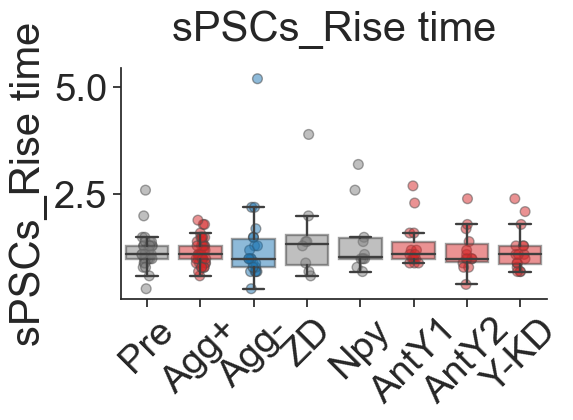

sPSCs (decay) ('Pre', 'Agg+') 0.37674432875524266
sPSCs (decay) ('Pre', 'Agg-') 0.5852881642217079
sPSCs (decay) ('Pre', 'npy1r_antag') 0.18937115235964863
sPSCs (decay) ('Pre', 'npy2r_antag') 0.4100454946750728
sPSCs (decay) ('Pre', 'npy_100') 0.28413078196034824
sPSCs (decay) ('Pre', 'ZD7288') 0.33514868886616145
sPSCs (decay) ('Pre', 'npykd') 0.457048180309247
sPSCs (decay) ('Agg+', 'Agg-') 0.9347974425566385
sPSCs (decay) ('Agg+', 'npy1r_antag') 0.4592162258702507
sPSCs (decay) ('Agg+', 'npy2r_antag') 0.7719401240708152
sPSCs (decay) ('Agg+', 'npy_100') 0.5613434398708197
sPSCs (decay) ('Agg+', 'ZD7288') 0.2615921304429486
sPSCs (decay) ('Agg+', 'npykd') 0.5110667411166248
sPSCs (decay) ('Agg-', 'npy1r_antag') 0.2752236364320767
sPSCs (decay) ('Agg-', 'npy2r_antag') 0.6016296673363777
sPSCs (decay) ('Agg-', 'npy_100') 0.6506095034649881
sPSCs (decay) ('Agg-', 'ZD7288') 0.3536940897929446
sPSCs (decay) ('Agg-', 'npykd') 0.6344757646596549
sPSCs (decay) ('npy1r_antag', 'npy2r_antag')

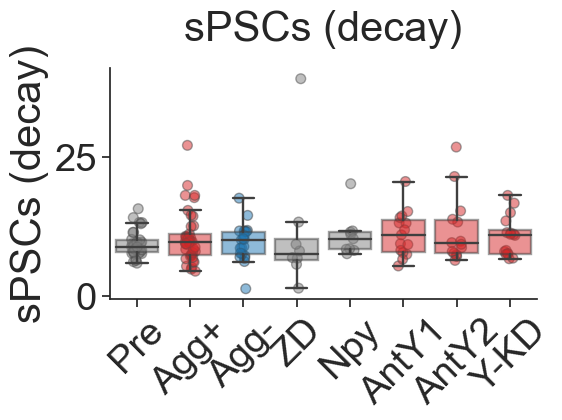

In [140]:
filter_cat = ['Pre', 'Agg+', 'Agg-', 'ZD7288', 'npy_100', 'npy1r_antag', 'npy2r_antag', 'npykd']


preprocess_plot(ephys[ephys.Behaviour_6hFD.isin(filter_cat)],'Behaviour_6hFD', 'pan', 
                palette=['Gray', 'Tab:red', 'Tab:Blue', 'Gray', 'Gray', 'Tab:red', 'Tab:red', 'Tab:red'], order = filter_cat,
                  plotting= True)


## Individual plots - panMPOA

In [23]:
trial = ephys[ephys.Behaviour_6hFD.isin(['Pre', 'Agg-', 'Agg+'])]
trial = trial.rename(columns={'Ih_at_-120mV': 'ih_current', 
                              'Firing_freq_(Hz)_I0': 'firing_freq', 
                              'sPSC_Amplitude(pA)': 'sPSC_Amplitude'})
model = smf.ols('Input_Resistance ~  ih_current  ', data=trial).fit()
#model.summary()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
ih_current,5.869880e+05,1.0,13.931079,0.000279
Residual,5.646109e+06,134.0,NaN,NaN


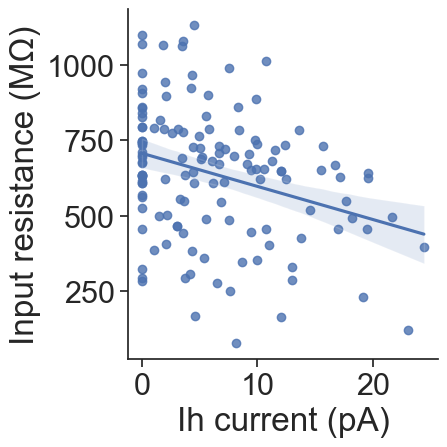

In [24]:
sns.lmplot(x = 'ih_current', y = 'Input_Resistance', data = trial, palette = ['darkgray', '#F97306', 'blue'])
plt.xlabel('Ih current (pA)')
plt.ylabel('Input resistance (MΩ)')
plt.savefig(f'output_figures/ih_input_resistance.png',dpi = 300, bbox_inches = 'tight')
          


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


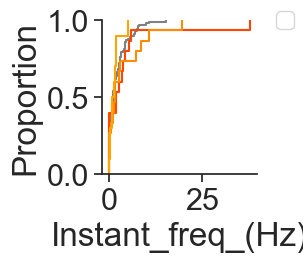

In [25]:
l = 'Instant_freq_(Hz)'
max = ephys[l].max()
cs = ['orange', 'darkorange', 'orangered', 'gray']
conds = ['npy_10', 'npy1r_antag', 'npy2r_antag', 'Pre']
fig, ax = plt.subplots(figsize=(2, 2))
sns.ecdfplot(data=ephys[ephys.Behaviour_6hFD.isin(conds)], x=l, hue="Behaviour_6hFD", hue_order = conds, palette = cs, ax = ax, )
sns.despine()
plt.legend(loc='center left', bbox_to_anchor=(1.05, 1), fontsize = 16)

plt.savefig(f'output_figures/ECDF_{l}.png',dpi = 300, bbox_inches = 'tight')
plt.show()

    

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


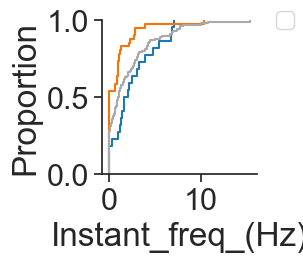

In [26]:
l = 'Instant_freq_(Hz)'
max = ephys[l].max()
cs = ['darkgray', '#F97306', 'Tab:blue']
conds = ['Pre', 'Agg+', 'Agg-']
fig, ax = plt.subplots(figsize=(2, 2))
sns.ecdfplot(data=ephys[ephys.Behaviour_6hFD.isin(conds)], x=l, hue="Behaviour_6hFD", palette = cs, ax = ax)
sns.despine()
plt.legend(loc='center left', bbox_to_anchor=(1.05, 1), fontsize = 16)

plt.savefig(f'output_figures/ECDF_{l}.png',dpi = 300, bbox_inches = 'tight')
plt.show()

    

### Individual plots Gal+ vs Gal-

In [27]:
# gals

In [28]:
print(f"Number of Gal+ neurons: {(gals['Gal_positive'] == 'yes').sum()} from {gals[gals['Gal_positive'] == 'yes']['ID_mouse'].nunique()} mice")
print(f"Number of Gal- neurons: {(gals['Gal_positive'] == 'no').sum()} from {gals[gals['Gal_positive'] == 'no']['ID_mouse'].nunique()} mice")


Number of Gal+ neurons: 9 from 3 mice
Number of Gal- neurons: 10 from 4 mice


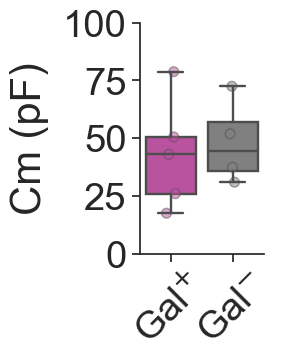

In [29]:
# Cm Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Cm(pF)', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Cm(pF)', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('Cm (pF)', labelpad=10)

ax.set_xticklabels((r'Gal$^{+}$', r'Gal$^{-}$'), rotation=45)

ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0,100)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Cm.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [30]:
# gals

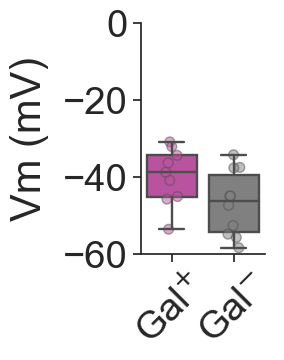

In [31]:
# Vm Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Vm', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Vm', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=10)

ax.set_xticklabels((r'Gal$^{+}$', r'Gal$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-60, 0)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Vm.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

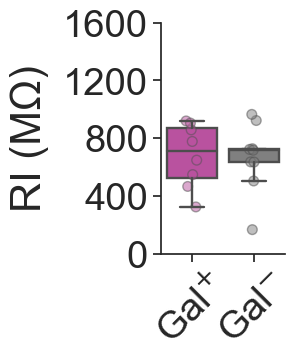

In [32]:
# RI Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Input_Resistance', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Input_Resistance', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=10)

ax.set_xticklabels((r'Gal$^{+}$', r'Gal$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0, 1600)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Ri.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

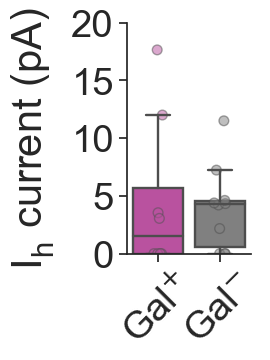

In [33]:
# Ih Gal+ vs Gal- 
sns.set(rc={"figure.figsize": (1.6, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Gal_positive', y='Ih_at_-120mV', data = gals, saturation=8, linewidth=1.7, showfliers = False, palette = dual)
ax = sns.stripplot(x='Gal_positive', y='Ih_at_-120mV', data = gals, jitter=True, dodge=False, marker='o', size=7, linewidth=1, 
                   edgecolor='gray', alpha=0.5, zorder=1, palette = dual)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ current (pA)', labelpad=10)

ax.set_xticklabels((r'Gal$^{+}$', r'Gal$^{-}$'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
plt.ylim(0, 20)
sns.despine()

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .7))
        
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/Ih.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

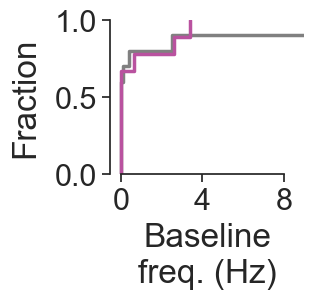

In [34]:
# Firing frequency Gal+ vs Gal-
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=gals, x="Firing_freq_(Hz)_I0", hue="Gal_positive", palette = dual, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_6/linked_figure_S6/ff.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

## silent proportion

I_zero_reclassified  phasic  silent  tonic  All
Behaviour_6hFD                                 
Agg+                      8      22     11   41
Agg-                      4       4     14   22
Pre                      18      27     55  100
All                      30      53     80  163
0.007964853254304776


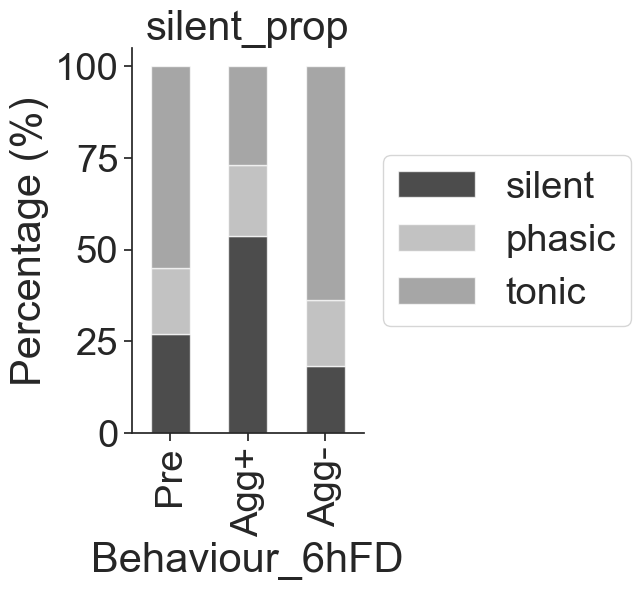

In [181]:
## silent proportion
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'Agg+', 'Agg-']
silent_prop = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero_reclassified', cols)
silent_prop['Behaviour_6hFD'] = pd.Categorical(silent_prop['Behaviour_6hFD'], cat)
silent_prop = silent_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(silent_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)
plt.title('silent_prop')
plt.savefig('output_figures/silent_prop.png',dpi = 300, bbox_inches = 'tight')

In [36]:
stats.chi2_contingency(silent_prop[cols])

In [37]:
silent_df

I_zero_reclassified,Behaviour_6hFD,silent
2,Pre,27.000000
0,Agg+,53.658537
1,Agg-,18.181818
3,ZD7288,88.888889
6,npy_100,63.636364
4,npy1r_antag,20.000000
5,npy2r_antag,40.000000
7,npykd,26.315789


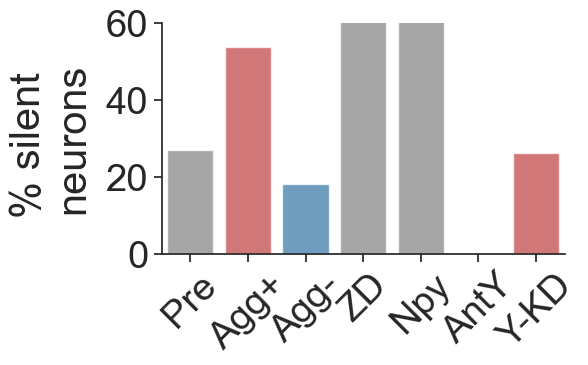

In [177]:
# % silent neurons - VERSION WITH ALL GROUPS
sns.set(rc={"figure.figsize": (5.2, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_df, x="Behaviour_6hFD", y="silent", order=['Pre', 'Agg+', 'Agg-', 'ZD7288','npy_100', 'npy_antag', 'npykd'],
                palette = sixtus, alpha=0.7)
g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('% silent \nneurons', labelpad=10)
g.set_xticklabels( ('Pre', 'Agg+', 'Agg-', 'ZD', 'Npy', 'AntY', 'Y-KD'), rotation=45)
plt.xlabel('')
plt.ylim(0,60)
sns.despine(bottom=False)
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/silent_prop_all.pdf',
dpi=300,bbox_inches='tight', transparent=True)

I_zero        phasic  silent  tonic  All
Gal_positive                            
no                 0       6      4   10
yes                1       6      2    9
All                1      12      6   19
0.44518771279268876


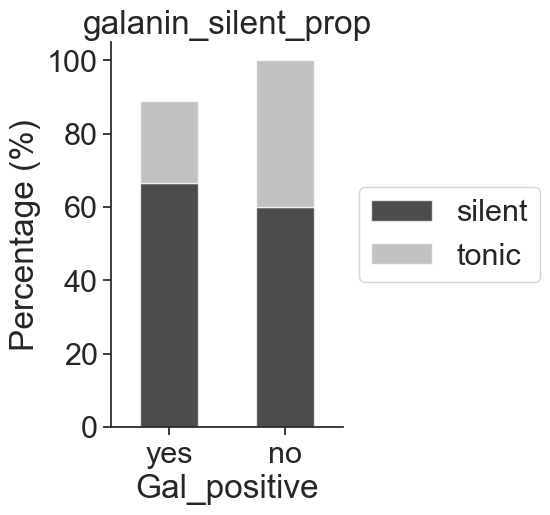

In [39]:
cols = ['silent', 'tonic']
silent_prop = proportion(gals, 'Gal_positive', 'I_zero', cols)
silent_prop['Gal_positive'] = pd.Categorical(silent_prop['Gal_positive'], ['yes', 'no'])
silent_prop = silent_prop.sort_values(by = ['Gal_positive'])
prop_plot(silent_prop, 'Gal_positive')
plt.title('galanin_silent_prop')
plt.savefig('output_figures/galanin_silent_prop.png',dpi = 300, bbox_inches = 'tight')

In [40]:
silent_prop

I_zero,Gal_positive,silent,tonic
1,yes,66.666667,22.222222
0,no,60.000000,40.000000


## adaptive prop

Adaptive        ?  no  yes  All
Behaviour_6hFD                 
Agg+            1  15   22   38
Agg-            0  18    3   21
Pre             1  15   23   39
All             2  48   48   98
0.0058942915757687646


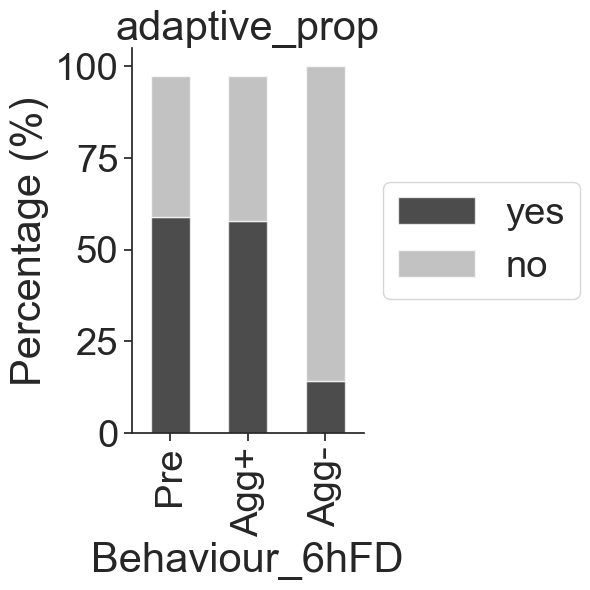

In [170]:
## adaptive proportion
cols = ['yes', 'no']
cat = ['Pre', 'Agg+', 'Agg-',]
ad_prop = proportion(ephys[ephys.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'Adaptive', cols)
ad_prop['Behaviour_6hFD'] = pd.Categorical(ad_prop['Behaviour_6hFD'], cat)
ad_prop = ad_prop.sort_values(by = ['Behaviour_6hFD'])

prop_plot(ad_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)
plt.title('adaptive_prop')
plt.savefig('output_figures/adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

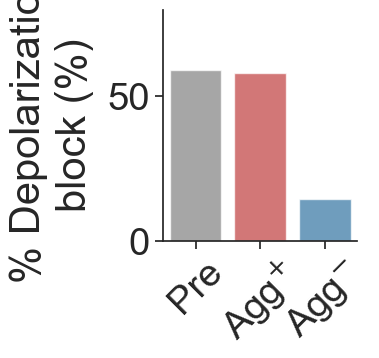

In [42]:
sns.set(rc={"figure.figsize": (2.5, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(x = 'Behaviour_6hFD', y = 'yes', data = ad_prop, order=['Pre', 'Agg+', 'Agg-'], palette= triple, alpha = 0.7)

g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('% Depolarization\nblock (%)', labelpad=10)
g.set_xticklabels(('Pre', r'Agg$^{+}$', r'Agg$^{-}$'), rotation=45)

plt.xlabel('')
plt.ylim(top=80)
plt.yticks(np.arange(0, 81, 50))
sns.despine(bottom=False)
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/linked_figure3/adaptive_prop.pdf',
dpi=300,bbox_inches='tight', transparent=True)

Adaptive      no  yes  All
Gal_positive              
no             5    3    8
yes            3    5    8
All            8    8   16
0.6170750774519739


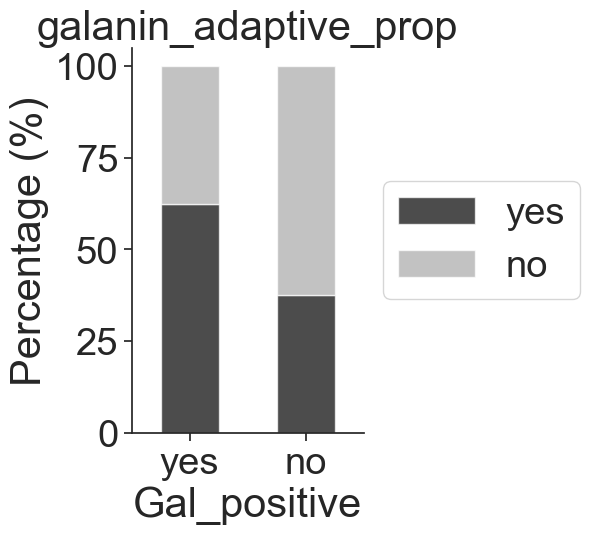

In [43]:
cols = ['yes', 'no']
ad_prop = proportion(gals, 'Gal_positive', 'Adaptive', cols)
ad_prop['Gal_positive'] = pd.Categorical(ad_prop['Gal_positive'], ['yes', 'no'])
ad_prop = ad_prop.sort_values(by = ['Gal_positive'])
prop_plot(ad_prop, 'Gal_positive')
plt.title('galanin_adaptive_prop')
plt.savefig('output_figures/galanin_adaptive_prop.png',dpi = 300, bbox_inches = 'tight')

## calcium T prop

cat_categ        no  no   yes  yes   All
Behaviour_6hFD                          
Agg+             23    0   16     0   39
Agg-              9    1   11     1   22
Pre              46    0   31     0   77
ZD7288            6    0    3     0    9
ZD7288_20         2    0    1     0    3
agrp_100         13    0    2     0   15
npy1r_antag       9    0    6     0   15
npy2r_antag       9    0    5     0   14
npy_10            7    1    2     0   10
npy_100           6    0    5     0   11
npy_antag        14    0    1     0   15
npykd            14    0    5     0   19
All             158    2   88     1  249
0.14175671177725893


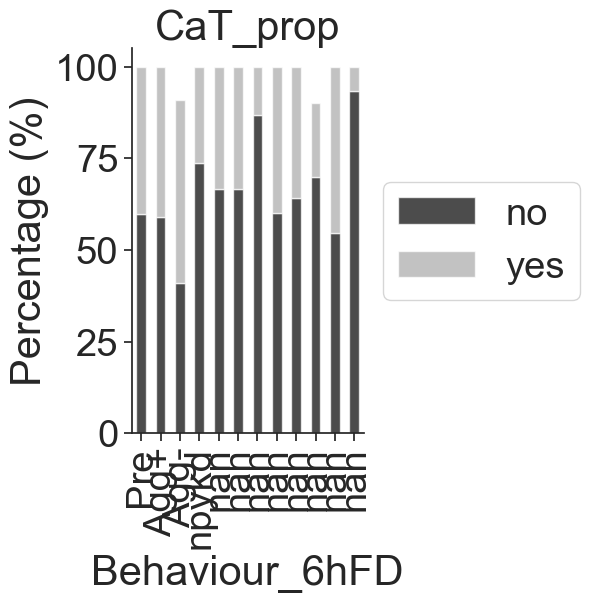

In [44]:
## calcium T proportion
cols = ['no', 'yes']
ca_prop = proportion(ephys, 'Behaviour_6hFD', 'cat_categ', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'],cat)
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')
plt.xticks(rotation = 90)

plt.title('CaT_prop')
plt.savefig('output_figures/CaT_prop.png',dpi = 300, bbox_inches = 'tight')

cat_categ     no  yes  All
Gal_positive              
no             4    6   10
yes            5    3    8
All            9    9   18
0.6352562959972483


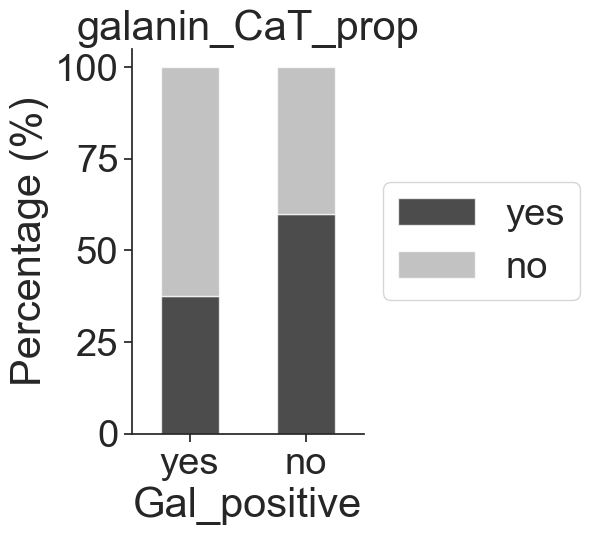

In [45]:
cols = ['yes', 'no']
ca_prop = proportion(gals, 'Gal_positive', 'cat_categ', cols)
ca_prop['Gal_positive'] = pd.Categorical(ca_prop['Gal_positive'], ['yes', 'no'])
ca_prop = ca_prop.sort_values(by = ['Gal_positive'])
prop_plot(ca_prop, 'Gal_positive')

plt.title('galanin_CaT_prop')
plt.savefig('output_figures/galanin_CaT_prop.png',dpi = 300, bbox_inches = 'tight')

## IH prop

IH              no  yes  All
Behaviour_6hFD              
Agg+            14   25   39
Agg-             1   21   22
Pre             23   54   77
ZD7288           9    0    9
ZD7288_20        3    0    3
agrp_100         6    9   15
npy1r_antag      4   11   15
npy2r_antag      2   12   14
npy_10           5    5   10
npy_100          6    5   11
npy_100_paired   2    1    3
npy_10_paired    0    5    5
npy_antag        3   12   15
npykd            1   18   19
All             79  178  257
1.1229631549053455e-06


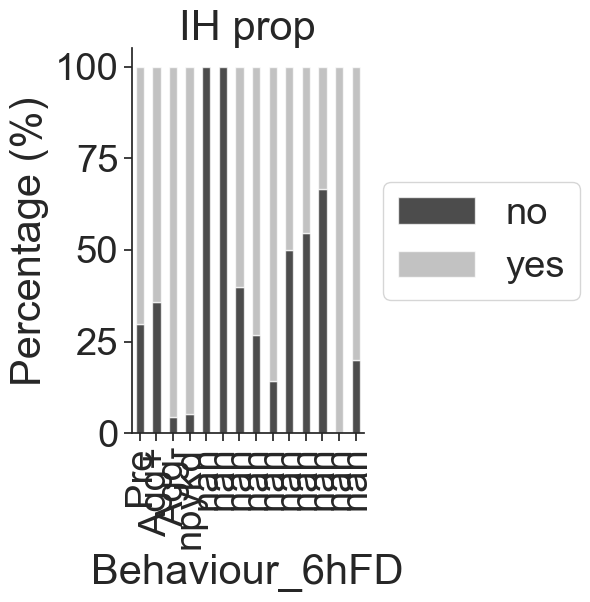

In [46]:
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'
cols = ['no', 'yes']

ca_prop = proportion(ephys, 'Behaviour_6hFD', 'IH', cols)
ca_prop['Behaviour_6hFD'] = pd.Categorical(ca_prop['Behaviour_6hFD'], cat)
ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ca_prop, 'Behaviour_6hFD')

plt.title('IH prop')
plt.xticks(rotation = 90)
plt.savefig('output_figures/IH_prop.png',dpi = 300, bbox_inches = 'tight')

IH                   no  yes  All
I_zero_reclassified              
phasic                6   38   44
silent               41   55   96
tonic                32   85  117
All                  79  178  257
0.001404601331864971


Text(0.5, 0, '')

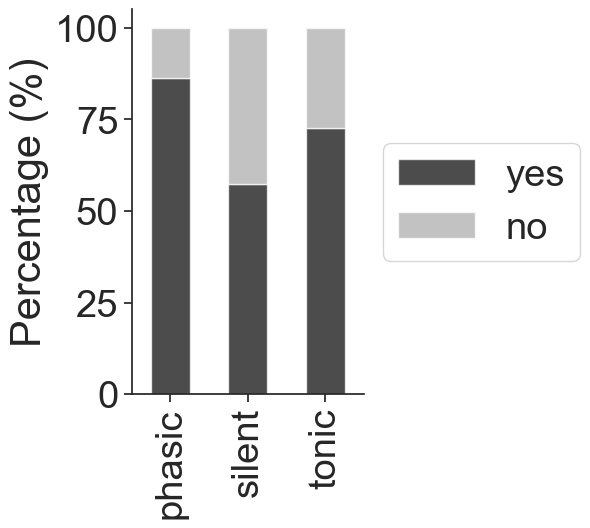

In [47]:
cols = ['yes', 'no']
ih_prop =  proportion(ephys, 'I_zero_reclassified', 'IH', cols)
# ca_prop = ca_prop.sort_values(by = ['Behaviour_6hFD'])
prop_plot(ih_prop, 'I_zero_reclassified')
plt.xticks(rotation = 90)
plt.xlabel('')

# Ramp analysis

In [48]:
from glob import glob
path = '/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/Analysis/Ramp'
states = ['Pre', 'Agg+', 'Agg-']
# list all directory in filepath
df_state = pd.DataFrame()

for state in states:
    files = [file for file in glob(f'{path}/{state}/*.xlsx')]
    df_files = []
    for file in files:
        try:
            df_file = pd.read_excel(file)
            df_file['filename'] = file
        except ValueError:
            print(file, state)
        df_files.append(df_file)

    df = pd.concat(df_files)
    df['state'] = state
    df_state = pd.concat([df_state, df])
    
        

/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Figure_3/Analysis/Ramp/Agg-/~$S1C4 16102023.xlsx Agg-


In [49]:
df_state

,Event,I_Injected(pA),Event start,Event end,Ramp_start,Ramp_end,filename,state
0,1.0,25.0,0.000000,0.000000,1080.0,2080.0,/Volumes/lab-kohlj/home/shared/projects/Negati...,Pre
1,2.0,35.0,0.000000,0.000000,1080.0,2080.0,/Volumes/lab-kohlj/home/shared/projects/Negati...,Pre
2,3.0,45.0,0.000000,0.000000,1080.0,2080.0,/Volumes/lab-kohlj/home/shared/projects/Negati...,Pre
3,4.0,55.0,0.000000,0.000000,1080.0,2080.0,/Volumes/lab-kohlj/home/shared/projects/Negati...,Pre
4,5.0,65.0,0.000000,0.000000,1080.0,2080.0,/Volumes/lab-kohlj/home/shared/projects/Negati...,Pre
...,...,...,...,...,...,...,...,...
230,15.0,165.0,1948.599976,1960.599976,1080.0,2080.0,/Volumes/lab-kohlj/home/shared/projects/Negati...,Agg-
231,15.0,165.0,1976.300049,1992.900024,1080.0,2080.0,/Volumes/lab-kohlj/home/shared/projects/Negati...,Agg-
232,15.0,165.0,2003.900024,2019.400024,1080.0,2080.0,/Volumes/lab-kohlj/home/shared/projects/Negati...,Agg-
233,15.0,165.0,2028.300049,2045.800049,1080.0,2080.0,/Volumes/lab-kohlj/home/shared/projects/Negati...,Agg-


In [50]:
df_state.rename(columns = {'I_Injected(pA)': 'Injected'}, inplace = True)
# df_state['Injected'] = pd.Categorical(df_state['Injected'], df_state['Injected'].unique()[:-2]).as_ordered()
df_state.sort_values('Injected', inplace = True)

df_state['state'] = pd.Categorical(df_state['state'], states).as_ordered()
# df_state.sort_values('Injected', inplace = True)


num_spike = df_state.groupby(by = ['filename', 'Injected']).size().reset_index(name ='num_spike')

df_all = df_state.groupby(['filename', 'Injected'], dropna = False).first().reset_index().drop_duplicates()

# df_state.loc[df['Event start '] == 0,'Event start '] = 2080
df_all['latency'] = df_all['Event start ']- df_all['Ramp_start']
df_all = df_all[df_all['latency'] > 0]
df_all['num_spike'] = num_spike.num_spike



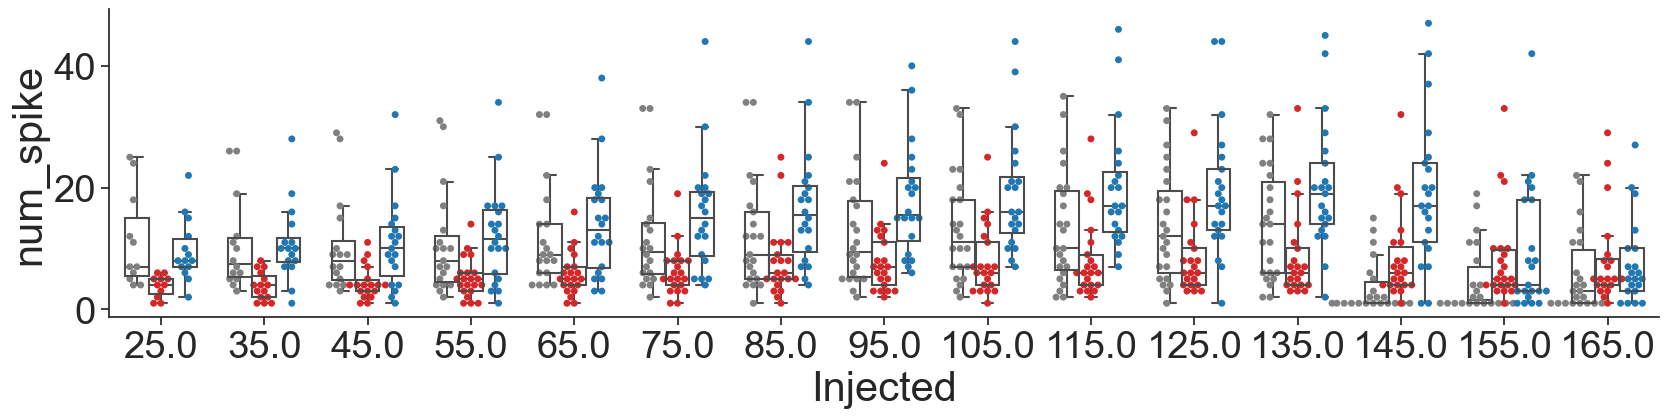

In [51]:
prop = 'num_spike'

fig, ax = plt.subplots(figsize = [20,4])

palette = ['gray', 'Tab:red', 'Tab:blue']
# df_all = df_all[df_all.state.isin(['Agg+', 'Pre'])]

sns.swarmplot(x  = 'Injected', y = prop, hue = 'state',
               dodge = True, data = df_all, palette=palette, ax=ax)

sns.boxplot(x  = 'Injected', y = prop, hue = 'state',
                data = df_all, saturation=1, showfliers=False,
            width=0.7, boxprops={'zorder': 3, 'facecolor': 'none'}, ax=ax)

# turn off legend
leg = ax.get_legend()
if leg:
    leg.remove()

    sns.despine()



In [52]:
model = smf.ols('latency ~ C(Injected) * C(state)', data=df_all).fit()
#model.summary()
sm.stats.anova_lm(model, typ=2)

,sum_sq,df,F,PR(>F)
C(Injected),2.791729e+06,14.0,2.896630,0.000265
C(state),8.702978e+05,2.0,6.320999,0.001884
C(Injected):C(state),1.845470e+06,28.0,0.957408,0.529442
Residual,5.837784e+07,848.0,NaN,NaN


# Estrous cycle influence

I_zero             phasic  silent  tonic  All
estrous_stage                                
?                       1       1      2    4
D                       5       7     15   27
E                       2       3      2    7
M                       2       6     14   22
P                       6       6     11   23
VS to be stained        0       0      1    1
no VS                   1       2      9   12
not taken               1       2      1    4
All                    18      27     55  100
0.8443773071908964
I_zero         phasic  silent  tonic  All
estrous_stage                            
?                   0       1      0    1
D                   2       7      6   15
E                   3       1      0    4
M                   2      10      3   15
P                   1       3      2    6
All                 8      22     11   41
0.17888737857066916


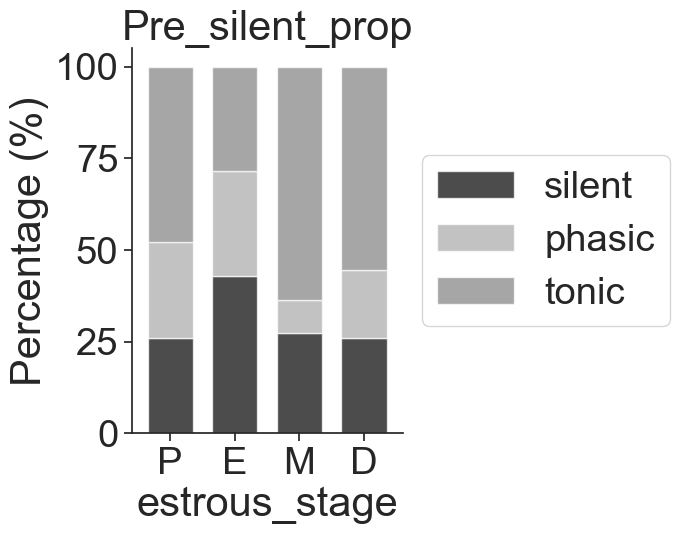

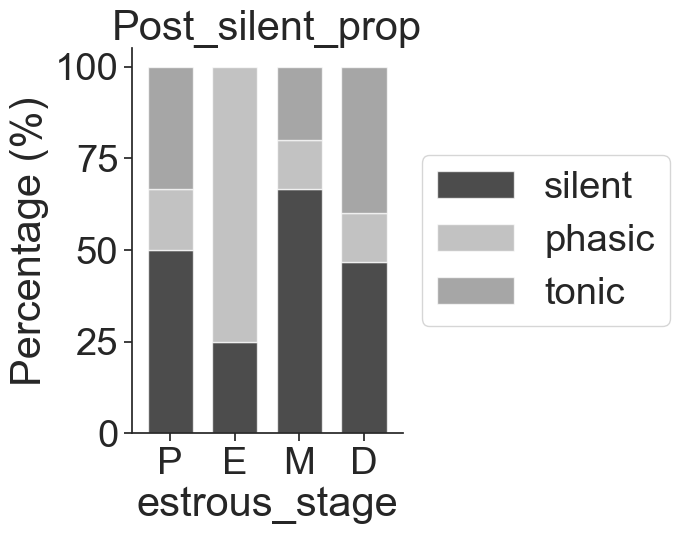

In [53]:
# silent proportion
ephys = pd.read_csv('sampled_ephys_data.csv')

ephys = ephys[ephys.I_zero.isin(['silent', 'phasic', 'tonic'])]
ephys.loc[(ephys['estrous_stage'] == 'P to E'), 'estrous_stage']  = 'P'
ephys.loc[(ephys['estrous_stage'] == 'D to P'), 'estrous_stage']  = 'D'
cols = ['silent', 'phasic', 'tonic']
ephys.loc[ephys.Behaviour_6hFD.isin(['Agg+']),'Behaviour_6hFD'] = 'Post'

for state in ['Pre', 'Post']:
    state_df = ephys[ephys.Behaviour_6hFD == state]
    silent_prop = proportion(state_df, 'estrous_stage', 'I_zero', cols)
    silent_prop['estrous_stage'] = pd.Categorical(silent_prop['estrous_stage'], ['P', 'E', 'M', 'D'])
    silent_prop = silent_prop.sort_values(by = ['estrous_stage'])
    silent_prop = silent_prop[silent_prop.estrous_stage.isin(['P', 'E', 'M', 'D'])]
    


    silent_prop.plot(x = 'estrous_stage', 
            kind = 'bar', 
            stacked = True,  
            mark_right = False,
            color = ['black', 'darkgray','gray'],
            figsize = (3.5,5), alpha = 0.7, width = 0.7)
 
        
    plt.xticks(rotation = 0)
    ax = plt.gca()
    plt.ylabel('Percentage (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    plt.title(f'{state}_silent_prop')
    plt.savefig(f'output_figures/{state}_silent_prop.png',dpi = 300, bbox_inches = 'tight')

0.9794583218927253 0.020541678107274697


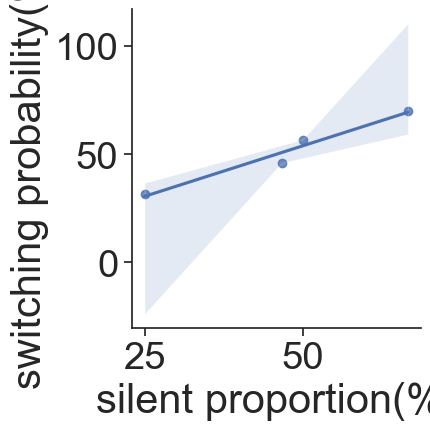

In [54]:
import scipy as sp
estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
corr = pd.merge(silent_prop, estrous_df, on = 'estrous_stage')

r, p = sp.stats.pearsonr(corr['switching probability'], corr['silent'])
print(r, p)
sns.lmplot(x = 'silent', y = 'switching probability', data = corr)
plt.xlabel('silent proportion(%)')
plt.ylabel('switching probability(%)')
plt.savefig('output_figures/silent_switching_corr.png', dpi = 300, bbox_inches = 'tight')

In [148]:
# import multiple comparison
from statsmodels.stats.multicomp import pairwise_tukeyhsd

Ih_at_-120mV 0.01761554472149117
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     D      E   0.3376 0.9993  -6.7879  7.4631  False
     D      M  -5.7214  0.022 -10.8225 -0.6203   True
     D      P   -0.911 0.9719  -6.4304  4.6084  False
     E      M   -6.059  0.126 -13.2289  1.1109  False
     E      P  -1.2487 0.9709   -8.722  6.2246  False
     M      P   4.8103 0.1143  -0.7663 10.3869  False
-----------------------------------------------------


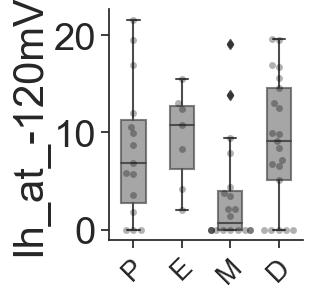

In [166]:
# IH current
ls = ['Cm(pF)', 'Firing_freq_(Hz)_I0','Instant_freq_(Hz)', 'isi_(ms)',  'CaT',  'Ih_at_-120mV', 'AP_ampl', 'AP_halfwidth', 'AP_time_to_peak','area(mV_ms)', 'rheobase_at_-60mV_(pA)', 'AHP_(mV)', 'Vm',
       'Input_Resistance', 'sPSC_frequency', 'sPSC_Amplitude(pA)','sPSCs_Rise time', 'sPSCs (decay)', 'AC-I0', 'AC_-60']

# ls = ['Ih_at_-120mV']

for state in ['Pre']:
    for column in ls:
        # state_df = ephys[ephys.Behaviour_6hFD == state]
        state_df = ephys.copy()
        state_df['estrous_stage'] = pd.Categorical(state_df['estrous_stage'], ['P', 'E', 'M', 'D'])
        state_df = state_df[state_df.Behaviour_6hFD == state]
        
        try:

            _, p = stats.f_oneway(state_df[column][state_df['estrous_stage'] == 'P'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'E'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'M'].dropna(),
                                    state_df[column][state_df['estrous_stage'] == 'D'].dropna())
        
            
            

            
            if p < 0.05:
                print(column , p)
                state_df = state_df.loc[:, ['estrous_stage', column]].dropna()
                multiple_comp_result = pairwise_tukeyhsd(endog=state_df[column],
                                         groups=state_df['estrous_stage'],
                                        alpha=0.05)
                print(multiple_comp_result.summary())

                fig,ax = plt.subplots(figsize = (2.5,3))
                sns.swarmplot(x='estrous_stage', y =column, data= state_df, alpha = 0.3, color = 'black')
                sns.boxplot(x='estrous_stage', y =column, data= state_df, boxprops=dict(alpha=0.7), width = 0.5, palette = ['gray'])
                sns.despine()
                plt.xticks(rotation = 45, fontsize = 20)
                # plt.ylabel('Ih current (pA)', fontsize = 25)
                plt.xlabel('')
            
                # plt.title(f'{state}_{column}', pad = 20)
                plt.savefig(f'output_figures/{state}_{column}.png',dpi = 300, bbox_inches = 'tight')
            
            plt.show()
        except Exception:
            continue

cat_categ          no  yes  All
estrous_stage                  
?                   1    3    4
D                  10   11   21
E                   3    4    7
M                  15    5   20
P                  14    6   20
VS to be stained    1    0    1
not taken           2    2    4
All                46   31   77
0.2559860927442175
cat_categ estrous_stage         no        yes
4                     P  70.000000  30.000000
2                     E  42.857143  57.142857
3                     M  75.000000  25.000000
1                     D  47.619048  52.380952


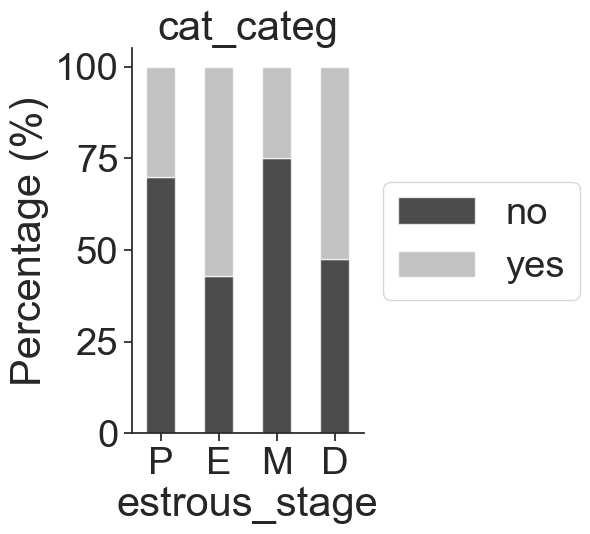

0.9437940453341869 0.05620595466581313


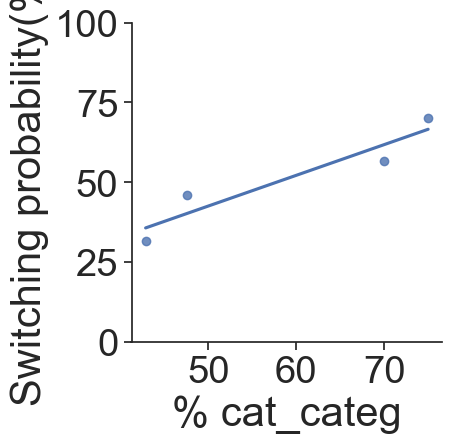

IH                 no  yes  All
estrous_stage                  
?                   0    4    4
D                   5   16   21
E                   0    7    7
M                  10   10   20
P                   5   15   20
VS to be stained    1    0    1
not taken           2    2    4
All                23   54   77
0.056205483511176685
IH estrous_stage         no         yes
4              P  25.000000   75.000000
2              E   0.000000  100.000000
3              M  50.000000   50.000000
1              D  23.809524   76.190476


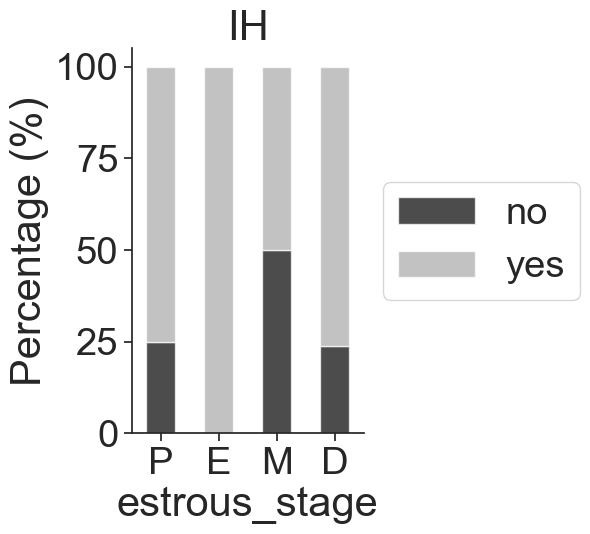

0.9687218215661222 0.03127817843387781


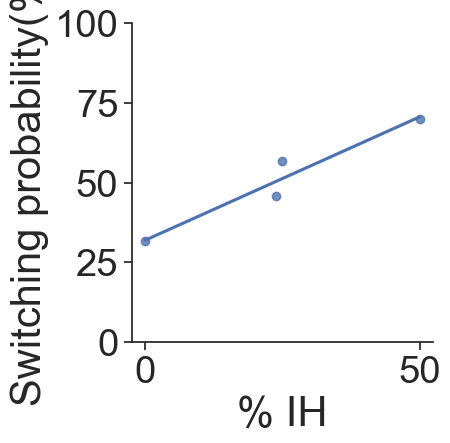

Adaptive           ?  no  yes  All
estrous_stage                     
?                  0   0    1    1
D                  0   4    5    9
E                  0   1    0    1
M                  0   7   10   17
P                  1   3    6   10
VS to be stained   0   0    1    1
All                1  15   23   39
0.803662355695632
Adaptive estrous_stage          no        yes
4                    P   30.000000  60.000000
2                    E  100.000000   0.000000
3                    M   41.176471  58.823529
1                    D   44.444444  55.555556


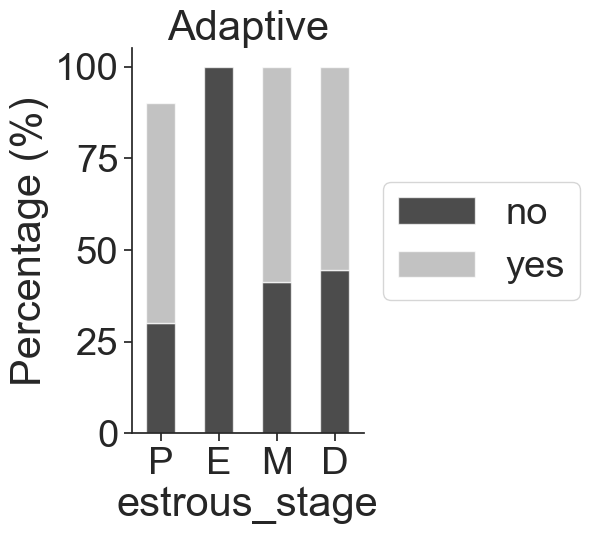

-0.7996129957560256 0.20038700424397438


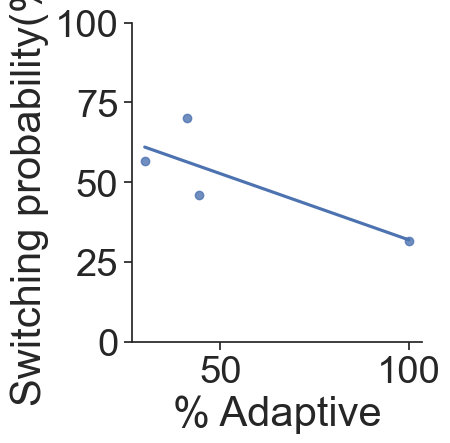

In [56]:
import scipy as sp
cols = ['no', 'yes']
ephys.loc[(ephys['Ih_at_-120mV'] == 0), 'IH']  = 'no'
ephys.loc[(ephys['Ih_at_-120mV'] >0 ), 'IH']  = 'yes'


estrous_df = pd.read_csv('../NPS_behaviour_analysis/generated_datasets/estrous_data.csv')
estrous_df.rename(columns = {'Unnamed: 0':'estrous_stage', '0':'switching probability'}, inplace = True)
ephys_pre = ephys[ephys.Behaviour_6hFD == 'Pre']

for column in ['cat_categ', 'IH', 'Adaptive']:
    esprop = proportion(ephys_pre, 'estrous_stage', column, cols)
    esprop['estrous_stage'] = pd.Categorical(esprop['estrous_stage'], ['P', 'E', 'M', 'D'])
    esprop = esprop.sort_values(by = ['estrous_stage']).dropna()
    prop_plot(esprop, 'estrous_stage')
    print(esprop)
    plt.title(column)
    plt.show()

    corr = pd.merge(esprop, estrous_df, on = 'estrous_stage')
    r, p = sp.stats.pearsonr(corr['switching probability'], corr['no'])
    print(r, p)

    sns.lmplot(x = 'no', y = 'switching probability', data = corr, ci = None)
    plt.ylim([0, 100])
    plt.xlabel(f'% {column}')
    plt.ylabel('Switching probability(%)')
    plt.savefig(f'output_figures/{column}_switching_corr.png', dpi = 300, bbox_inches = 'tight')
    plt.show()

IH                 no  yes  All
estrous_stage                  
?                   0    4    4
D                   5   16   21
E                   0    7    7
M                  10   10   20
P                   5   15   20
VS to be stained    1    0    1
not taken           2    2    4
All                23   54   77
0.056205483511176685
Adaptive           ?  no  yes  All
estrous_stage                     
?                  0   0    1    1
D                  0   4    5    9
E                  0   1    0    1
M                  0   7   10   17
P                  1   3    6   10
VS to be stained   0   0    1    1
All                1  15   23   39
0.803662355695632
-0.4469053317142255 0.5530946682857745


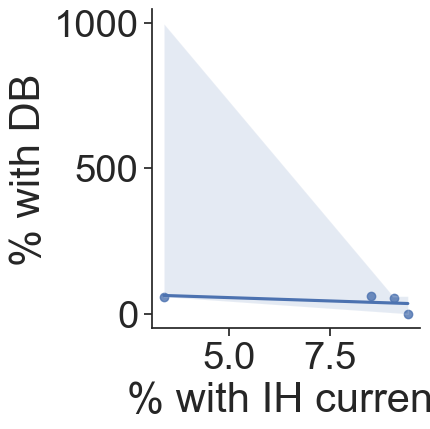

In [57]:

cols = ['no', 'yes']
estrous_stages = ['P', 'E', 'M', 'D']
ih_prop = proportion(ephys_pre, 'estrous_stage', 'IH', cols)
ih_est_mean = ephys_pre.groupby('estrous_stage')['Ih_at_-120mV'].mean().reset_index()
adaptive_prop = proportion(ephys_pre, 'estrous_stage', 'Adaptive', cols)
merged_df = pd.merge(ih_est_mean, adaptive_prop, on = 'estrous_stage')
merged_df = merged_df[merged_df.estrous_stage.isin(estrous_stages)]


r, p = sp.stats.pearsonr(merged_df['Ih_at_-120mV'], merged_df['yes'])
print(r, p)

sns.lmplot(x = 'Ih_at_-120mV', y = 'yes', data = merged_df)
# plt.ylim([0, /100])
plt.xlabel('% with IH current')
plt.ylabel('% with DB')
plt.show()

## Individual plots

### Pre

In [58]:
# We're plotting by estrous state from all 'Pre' values here
ephys_estrous = ephys[ephys['Behaviour_6hFD'] == 'Pre']

In [59]:
print(f"Number of P neurons: {(ephys_estrous['estrous_stage'] == 'P').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'P']['ID_mouse'].nunique()} mice")
print(f"Number of E neurons: {(ephys_estrous['estrous_stage'] == 'E').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'E']['ID_mouse'].nunique()} mice")
print(f"Number of M neurons: {(ephys_estrous['estrous_stage'] == 'M').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'M']['ID_mouse'].nunique()} mice")
print(f"Number of D neurons: {(ephys_estrous['estrous_stage'] == 'D').sum()} from {ephys_estrous[ephys_estrous['estrous_stage'] == 'D']['ID_mouse'].nunique()} mice")

Number of P neurons: 23 from 7 mice
Number of E neurons: 7 from 2 mice
Number of M neurons: 22 from 4 mice
Number of D neurons: 27 from 2 mice


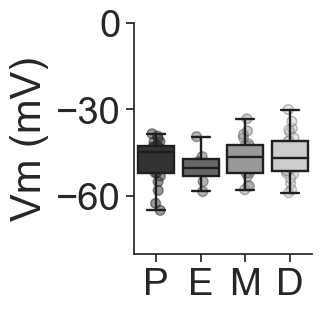

In [60]:
# Membrane voltage - estrous Pre

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Vm', data = ephys_estrous, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Vm', data = ephys_estrous, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Vm_estrous_pre.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

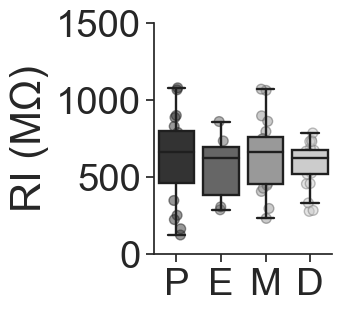

In [61]:
# Input resistance - estrous Pre

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Input_Resistance', data = ephys_estrous, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Input_Resistance', data = ephys_estrous, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ri_estrous_pre.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

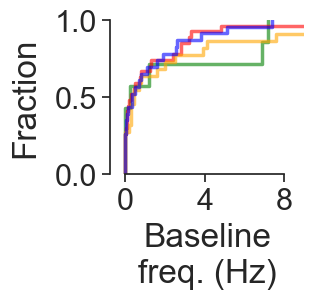

In [62]:
# Firing frequency - estrous Pre

# 'estrous_stage' contains entries that are not P, E, M or D. Filter those out first.
custom_palette = {'P': 'blue', 'E': 'green', 'M': 'orange', 'D': 'red'}
valid_estrous_stages = ['P', 'E', 'M', 'D']
ephys_estrous2 = ephys_estrous[ephys_estrous['estrous_stage'].isin(valid_estrous_stages)]

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_estrous2, x="Firing_freq_(Hz)_I0", hue="estrous_stage", linewidth=2.5, legend=False,
                   stat='proportion', palette = custom_palette, alpha=.6)
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/ff_estrous_pre.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

### Post (Agg+/- pooled)

In [63]:
# We're plotting by estrous state from all 'Agg+' and 'Agg-' values here
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys_post = ephys[(ephys['Behaviour_6hFD'] == 'Agg+') | (ephys['Behaviour_6hFD'] == 'Agg-')]

In [64]:
print(f"Number of P neurons: {(ephys_post['estrous_stage'] == 'P').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'P']['ID_mouse'].nunique()} mice")
print(f"Number of E neurons: {(ephys_post['estrous_stage'] == 'E').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'E']['ID_mouse'].nunique()} mice")
print(f"Number of M neurons: {(ephys_post['estrous_stage'] == 'M').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'M']['ID_mouse'].nunique()} mice")
print(f"Number of D neurons: {(ephys_post['estrous_stage'] == 'D').sum()} from {ephys_post[ephys_post['estrous_stage'] == 'D']['ID_mouse'].nunique()} mice")

Number of P neurons: 12 from 2 mice
Number of E neurons: 4 from 1 mice
Number of M neurons: 25 from 4 mice
Number of D neurons: 13 from 3 mice


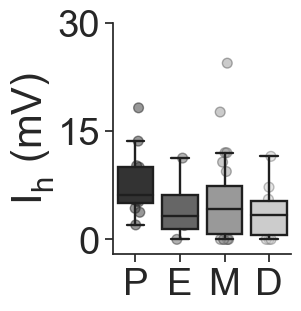

In [65]:
# Ih - Post
sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Ih_at_-120mV', data = ephys_post, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Ih_at_-120mV', data = ephys_post, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ (mV)', labelpad=0)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-2, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ih_estrous_post.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

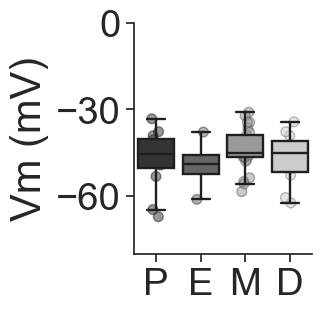

In [66]:
# Membrane voltage - estrous Post

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Vm', data = ephys_post, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Vm', data = ephys_post, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Vm_estrous_post.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

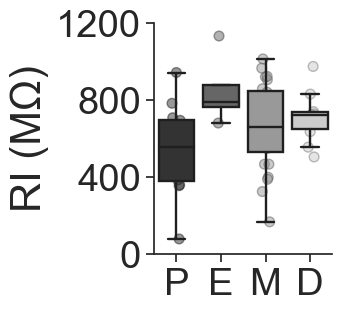

In [67]:
# Input resistance - estrous Post

sns.set(rc={"figure.figsize": (2.3, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='estrous_stage', y='Input_Resistance', data = ephys_post, order=['P', 'E', 'M', 'D'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = 'gray')
ax = sns.stripplot(x='estrous_stage', y='Input_Resistance', data = ephys_post, order=['P', 'E', 'M', 'D'], jitter=True, dodge=False, 
                   marker='o', size=7, linewidth=1, edgecolor='gray', palette = 'gray', alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('P', 'E', 'M', 'D'))
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1200)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/Ri_estrous_post.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

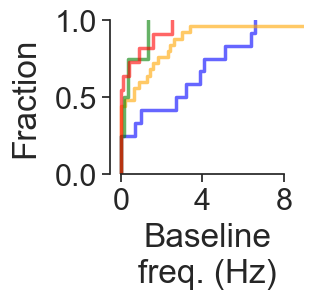

In [68]:
# Firing frequency - estrous Post

# 'estrous_stage' contains entries that are not P, E, M or D. Filter those out first. NOTE THAT THIS REMOVES E.G. 'P to E' ETC. 
#- IT MIGHT BE BETTER TO RECLASSIFY THOSE
custom_palette = {'P': 'blue', 'E': 'green', 'M': 'orange', 'D': 'red'}
valid_estrous_stages = ['P', 'E', 'M', 'D']
ephys_post2 = ephys_post[ephys_post['estrous_stage'].isin(valid_estrous_stages)]

sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_post2, x="Firing_freq_(Hz)_I0", hue="estrous_stage", linewidth=2.5, legend=False,
                   stat='proportion', palette = custom_palette, alpha=.6)
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

# plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_8/linked_figure_S8/ff_estrous_post.pdf',
#             dpi=300,bbox_inches='tight', transparent=True)

# NPY administration

In [71]:
# reload data and convert all instances of NPY application to 'npy'
# UPDATE: use updated npy_100 column!
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys_npy = ephys.copy()
# ephys_npy['Behaviour_6hFD'] = ephys_npy['Behaviour_6hFD'].replace(['npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100'], 'npy')


In [72]:
print(f"Number of Pre neurons: {(ephys_npy['Behaviour_6hFD'] == 'Pre').sum()} from {ephys_npy[ephys_npy['Behaviour_6hFD'] == 'Pre']['ID_mouse'].nunique()} mice")
print(f"Number of NPY neurons: {(ephys_npy['Behaviour_6hFD'] == 'npy_100').sum()} from {ephys_npy[ephys_npy['Behaviour_6hFD'] == 'npy_100']['ID_mouse'].nunique()} mice")

Number of Pre neurons: 102 from 12 mice
Number of NPY neurons: 11 from 4 mice


In [73]:
# ephys_npy

In [74]:
ephys_npy.Behaviour_6hFD.unique()

array(['Pre', 'Agg+', 'Agg-', 'npy_antag', 'npy1r_antag', 'npy2r_antag',
       'npy_10_paired', 'npy_10', 'npy_100_paired', 'npy_100', 'agrp_100',
       'ZD7288', 'ZD7288_20', 'npykd'], dtype=object)

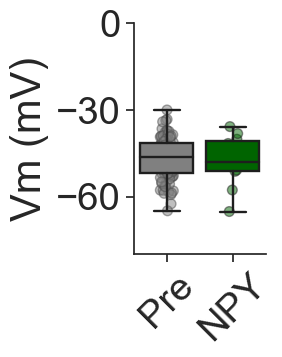

In [75]:
# Membrane voltage / RMP + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys_npy, order=['Pre', 'npy_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = npy)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys_npy, order = ['Pre', 'npy_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = npy, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'NPY'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Vm_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

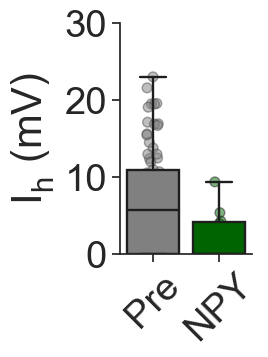

In [76]:
# Ih + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_npy, order=['Pre', 'npy_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = npy)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_npy, order = ['Pre', 'npy_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = npy, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'NPY'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ih_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

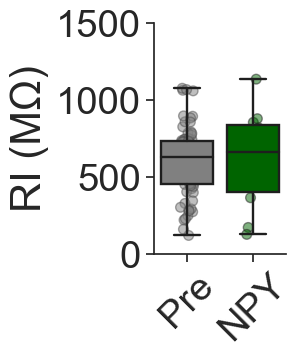

In [77]:
# RI + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_npy, order=['Pre', 'npy_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = npy)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_npy, order = ['Pre', 'npy_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = npy, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('Pre', 'NPY'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ri_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [78]:
# Proportion of silent neurons 
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'npy_100']
silent_npy = proportion(ephys_npy[ephys_npy.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero', cols)
silent_npy['Behaviour_6hFD'] = pd.Categorical(silent_npy['Behaviour_6hFD'], cat)
silent_npy = silent_npy.sort_values(by = ['Behaviour_6hFD'])

I_zero          phasic  silent  tonic  All
Behaviour_6hFD                            
Pre                 18      27     55  100
npy_100              2       7      2   11
All                 20      34     57  111
0.03082748617552394


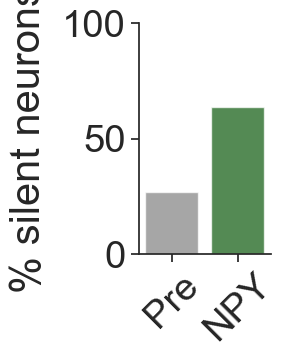

In [79]:
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_npy, x="Behaviour_6hFD", y="silent", order=['Pre', 'npy_100'], palette = npy, alpha=0.7)
g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('% silent neurons', labelpad=10)
g.set_xticklabels(('Pre', 'NPY'), rotation=45)
plt.xlabel('')
plt.yticks(np.arange(0, 101, 50))
plt.ylim(0,100)
# ax.yaxis.set_major_locator(plt.MaxNLocator(5))
sns.despine()
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/silent_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [80]:
# subset df for those groups needed for firing freq. plot
ephys_npy_ff = ephys_npy.loc[(ephys_npy['Behaviour_6hFD'] == 'Pre') | (ephys_npy['Behaviour_6hFD'] == 'npy_100')]

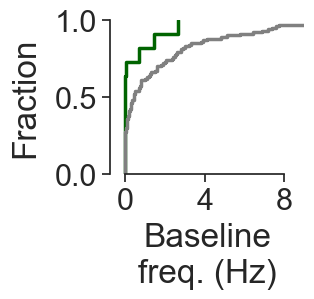

In [81]:
# Firing frequency
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_npy_ff, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = npy, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/ff_npy.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

# AgRP administration

In [82]:
# reload data and convert all instances of AgRP application to 'agrp'
# UPDATE: use the updated agrp_100 column!
ephys = pd.read_csv('sampled_ephys_data.csv')
ephys_agrp = ephys.copy()
# ephys_agrp['Behaviour_6hFD'] = ephys_agrp['Behaviour_6hFD'].replace(['agrp_100_paired', 'agrp_100'], 'agrp')

In [83]:
# ephys_agrp.Behaviour_6hFD.unique()

In [84]:
print(f"Number of Pre neurons: {(ephys_agrp['Behaviour_6hFD'] == 'Pre').sum()} from {ephys_agrp[ephys_agrp['Behaviour_6hFD'] == 'Pre']['ID_mouse'].nunique()} mice")
print(f"Number of AgRP neurons: {(ephys_agrp['Behaviour_6hFD'] == 'agrp_100').sum()} from {ephys_agrp[ephys_agrp['Behaviour_6hFD'] == 'agrp_100']['ID_mouse'].nunique()} mice")

Number of Pre neurons: 102 from 12 mice
Number of AgRP neurons: 15 from 5 mice


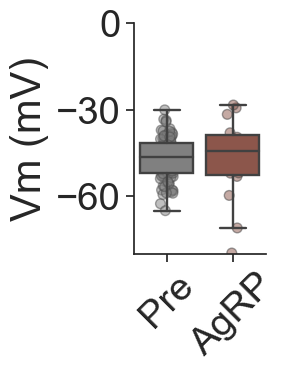

In [85]:
# Membrane voltage / RMP + AgRP

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Vm', data = ephys_agrp, order=['Pre', 'agrp_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = agrp)
ax = sns.stripplot(x='Behaviour_6hFD', y='Vm', data = ephys_agrp, order = ['Pre', 'agrp_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = agrp, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('Vm (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'AgRP'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(-80, 0)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Vm_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

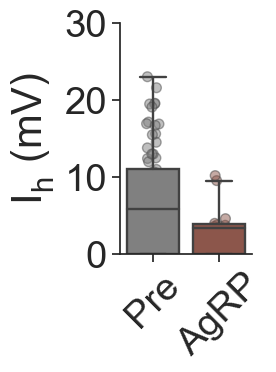

In [86]:
# Ih + AgRP

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_agrp, order=['Pre', 'agrp_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = agrp)
ax = sns.stripplot(x='Behaviour_6hFD', y='Ih_at_-120mV', data = ephys_agrp, order = ['Pre', 'agrp_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = agrp, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('$\mathregular{I_{h}}$ (mV)', labelpad=5)

ax.set_xticklabels( ('Pre', 'AgRP'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 30)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ih_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

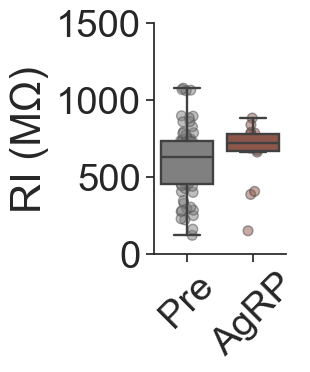

In [87]:
# RI + NPY

sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

ax = sns.boxplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_agrp, order=['Pre', 'agrp_100'], saturation=8, 
                 linewidth=1.7, showfliers = False, palette = agrp)
ax = sns.stripplot(x='Behaviour_6hFD', y='Input_Resistance', data = ephys_agrp, order = ['Pre', 'agrp_100'], jitter=True, 
                   dodge=False, marker='o', size=7, linewidth=1, edgecolor='gray', palette = agrp, alpha=0.5, zorder=0)
ax.set_xlabel('')
ax.set_ylabel('RI (MΩ)', labelpad=5)

ax.set_xticklabels( ('Pre', 'AgRP'), rotation=45)
ax.yaxis.set_major_locator(plt.MaxNLocator(3))
plt.ylim(0, 1500)
sns.despine(bottom=False, trim=False)

for patch in ax.artists:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, .5))
    
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/Ri_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [88]:
# Proportion of silent neurons 
cols = ['silent', 'phasic', 'tonic']
cat = ['Pre', 'agrp_100']
silent_agrp = proportion(ephys_agrp[ephys_agrp.Behaviour_6hFD.isin(cat)], 'Behaviour_6hFD', 'I_zero', cols)
silent_agrp['Behaviour_6hFD'] = pd.Categorical(silent_agrp['Behaviour_6hFD'], cat)
silent_agrp = silent_agrp.sort_values(by = ['Behaviour_6hFD'])

I_zero          phasic  silent  tonic  All
Behaviour_6hFD                            
Pre                 18      27     55  100
agrp_100             2       5      8   15
All                 20      32     63  115
0.8361193092718071


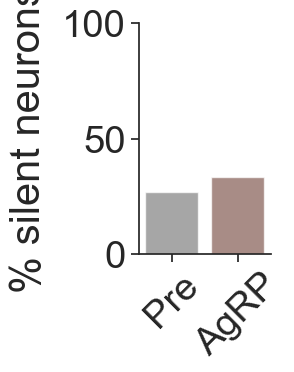

In [89]:
sns.set(rc={"figure.figsize": (1.7, 3)})
sns.set(font_scale=2.5) 
sns.set_style("ticks")

g = sns.barplot(silent_agrp, x="Behaviour_6hFD", y="silent", order=['Pre', 'agrp_100'], palette = agrp, alpha=0.7)
g.yaxis.set_major_locator(plt.MaxNLocator(3)) 
plt.ylabel('% silent neurons', labelpad=10)
g.set_xticklabels(('Pre', 'AgRP'), rotation=45)
plt.xlabel('')
plt.yticks(np.arange(0, 101, 50))
plt.ylim(0,100)
sns.despine()
plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/silent_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)

In [90]:
# subset df for those groups needed for firing freq. plot
ephys_agrp_ff = ephys_agrp.loc[(ephys_agrp['Behaviour_6hFD'] == 'Pre') | (ephys_agrp['Behaviour_6hFD'] == 'agrp_100')]

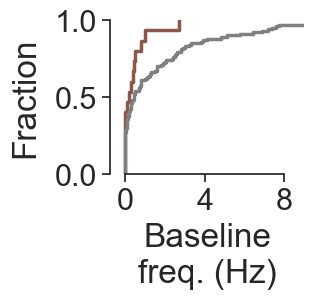

In [91]:
# Firing frequency
sns.set(rc={"figure.figsize": (2.5, 2.0)})
sns.set(font_scale=2) 
sns.set_style("ticks")

cum = sns.ecdfplot(data=ephys_agrp_ff, x="Firing_freq_(Hz)_I0", hue="Behaviour_6hFD", palette = agrp, linewidth=2.5, legend=False, stat='proportion')
cum.set_xlabel('Baseline\nfreq. (Hz)',labelpad=5)
cum.set_ylabel('Fraction',labelpad=10)
cum.xaxis.set_major_locator(plt.MaxNLocator(3))
plt.xlim(right=9)
sns.despine(trim=True)

plt.savefig('/Volumes/lab-kohlj/home/shared/projects/NegativeParentalSwitch/figures/Supp_Fig_7/linked_figure_S7/ff_agrp.pdf',
            dpi=300,bbox_inches='tight', transparent=True)